# MonolithFarm — Notebook didático com foco em NDVI

Este notebook foi reorganizado para duas finalidades ao mesmo tempo:

1. **entender o projeto de ponta a ponta**;
2. **servir como material de apresentação**.

O foco principal é o **NDVI**. Clima, operação, pragas e solo aparecem aqui como variáveis que ajudam a explicar o comportamento do NDVI ao longo do tempo.


In [1]:
from __future__ import annotations

import importlib.util
import json
import os
import subprocess
import sys
from pathlib import Path


OUTPUT_SUBDIR = 'complete_ndvi'
NOTEBOOK_MODE = os.environ.get("MONOLITHFARM_NOTEBOOK_MODE", "auto").strip().lower()
if NOTEBOOK_MODE not in {"auto", "jupyter", "colab"}:
    raise ValueError("MONOLITHFARM_NOTEBOOK_MODE deve ser `auto`, `jupyter` ou `colab`.")

PROFILE_NAME = os.environ.get("MONOLITHFARM_PROFILE", "").strip()
CONFIG_ENV_PATH = os.environ.get("MONOLITHFARM_PATHS_FILE", "").strip()
IN_COLAB_RUNTIME = "google.colab" in sys.modules
USE_COLAB_MODE = NOTEBOOK_MODE == "colab" or (NOTEBOOK_MODE == "auto" and IN_COLAB_RUNTIME)
REQUIRED_PACKAGES = ['duckdb', 'matplotlib', 'numpy', 'pandas', 'pyproj', 'scipy', 'shapely']
COLAB_PROJECT_HINTS = [
    "/content/drive/MyDrive/MonolithFarm",
    "/content/drive/My Drive/MonolithFarm",
    "/content/Projeto-FarmLab",
    "/content/MonolithFarm",
]
COLAB_DATA_HINTS = [f"{project_dir}/data" for project_dir in COLAB_PROJECT_HINTS]


def package_available(name: str) -> bool:
    return importlib.util.find_spec(name) is not None


def first_existing_path(candidates: list[str]) -> Path | None:
    for candidate in candidates:
        path = Path(candidate).expanduser()
        if path.exists():
            return path.resolve()
    return None


def discover_paths_config_file() -> Path | None:
    candidates: list[Path] = []
    if CONFIG_ENV_PATH:
        candidates.append(Path(CONFIG_ENV_PATH).expanduser())

    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        candidates.append(candidate / ".monolithfarm.paths.json")
        candidates.append(candidate / "monolithfarm.paths.json")

    seen: set[str] = set()
    for candidate in candidates:
        resolved = candidate.resolve() if candidate.is_absolute() else candidate
        key = str(resolved)
        if key in seen:
            continue
        seen.add(key)
        if resolved.exists():
            return resolved
    return None


def load_paths_config() -> tuple[dict, Path | None]:
    config_path = discover_paths_config_file()
    if config_path is None:
        return {}, None

    payload = json.loads(config_path.read_text(encoding="utf-8"))
    if not isinstance(payload, dict):
        raise ValueError(f"Arquivo de configuracao invalido: {config_path}")
    return payload, config_path


PATHS_CONFIG, PATHS_CONFIG_FILE = load_paths_config()
CONFIG_BASE_DIR = PATHS_CONFIG_FILE.parent.resolve() if PATHS_CONFIG_FILE is not None else None
DEFAULT_PROFILE = str(PATHS_CONFIG.get("default_profile") or "").strip()
ACTIVE_PROFILE = PROFILE_NAME or DEFAULT_PROFILE
PROFILE_SETTINGS = {}
if ACTIVE_PROFILE:
    profiles = PATHS_CONFIG.get("profiles", {})
    if ACTIVE_PROFILE not in profiles:
        raise KeyError(
            f"Perfil `{ACTIVE_PROFILE}` nao encontrado em {PATHS_CONFIG_FILE}."
        )
    profile_value = profiles.get(ACTIVE_PROFILE)
    if isinstance(profile_value, dict):
        PROFILE_SETTINGS = profile_value
elif isinstance(PATHS_CONFIG.get("profile"), dict):
    PROFILE_SETTINGS = PATHS_CONFIG["profile"]


def config_value(key: str):
    return PROFILE_SETTINGS.get(key) if isinstance(PROFILE_SETTINGS, dict) else None


def resolve_config_path(raw_value: object, *, base_dir: Path | None) -> Path | None:
    if raw_value in {None, ""}:
        return None
    path = Path(str(raw_value)).expanduser()
    if not path.is_absolute() and base_dir is not None:
        path = (base_dir / path).resolve()
    else:
        path = path.resolve()
    return path


def mount_colab_drive_if_needed() -> None:
    if not USE_COLAB_MODE:
        return
    if not IN_COLAB_RUNTIME:
        raise RuntimeError(
            "MONOLITHFARM_NOTEBOOK_MODE='colab' foi definido, mas o runtime atual nao e Google Colab."
        )
    from google.colab import drive

    drive_root = Path("/content/drive")
    drive_root.mkdir(parents=True, exist_ok=True)
    if not (drive_root / "MyDrive").exists() and not (drive_root / "My Drive").exists():
        drive.mount("/content/drive")


def find_project_dir() -> Path:
    explicit = os.environ.get("MONOLITHFARM_PROJECT_DIR")
    if explicit:
        return Path(explicit).expanduser().resolve()

    config_project_dir = resolve_config_path(config_value("project_dir"), base_dir=CONFIG_BASE_DIR)
    if config_project_dir is not None:
        return config_project_dir

    if USE_COLAB_MODE:
        hinted_project = first_existing_path(COLAB_PROJECT_HINTS)
        if hinted_project is not None and (hinted_project / "pyproject.toml").exists():
            return hinted_project
        hinted_data = first_existing_path(COLAB_DATA_HINTS)
        if hinted_data is not None and (hinted_data.parent / "pyproject.toml").exists():
            return hinted_data.parent.resolve()

    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError(
        "Nao foi possivel localizar `pyproject.toml`. Defina MONOLITHFARM_PROJECT_DIR, "
        "MONOLITHFARM_PROFILE ou crie `.monolithfarm.paths.json`."
    )


def find_data_dir(project_dir: Path) -> Path:
    explicit = os.environ.get("MONOLITHFARM_DATA_DIR")
    if explicit:
        return Path(explicit).expanduser().resolve()

    config_data_dir = resolve_config_path(config_value("data_dir"), base_dir=CONFIG_BASE_DIR)
    if config_data_dir is not None:
        return config_data_dir

    if USE_COLAB_MODE:
        hinted_data = first_existing_path(COLAB_DATA_HINTS)
        if hinted_data is not None:
            return hinted_data

    for candidate in [project_dir / "data", project_dir / "FarmLab"]:
        if candidate.exists():
            return candidate.resolve()

    return (project_dir / "data").resolve()


def find_output_dir(project_dir: Path) -> Path:
    explicit = os.environ.get("MONOLITHFARM_OUTPUT_DIR")
    if explicit:
        return Path(explicit).expanduser().resolve()

    config_output_dir = resolve_config_path(config_value("output_dir"), base_dir=CONFIG_BASE_DIR)
    if config_output_dir is not None:
        return config_output_dir

    config_output_root = resolve_config_path(config_value("output_root"), base_dir=CONFIG_BASE_DIR)
    if config_output_root is not None:
        return (config_output_root / OUTPUT_SUBDIR).resolve()

    return (project_dir / OUTPUT_SUBDIR).resolve()


def auto_install_enabled() -> bool:
    explicit = os.environ.get("MONOLITHFARM_AUTO_INSTALL")
    if explicit is not None:
        return explicit == "1"

    config_auto_install = config_value("auto_install")
    if config_auto_install is not None:
        return bool(config_auto_install)

    return USE_COLAB_MODE


mount_colab_drive_if_needed()
PROJECT_DIR = find_project_dir()
DATA_DIR = find_data_dir(PROJECT_DIR)
OUTPUT_DIR = find_output_dir(PROJECT_DIR)
AUTO_INSTALL = auto_install_enabled()

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

if AUTO_INSTALL and any(not package_available(name) for name in REQUIRED_PACKAGES):
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(PROJECT_DIR)])
    except Exception:
        subprocess.check_call(["uv", "pip", "install", "--python", sys.executable, "-e", str(PROJECT_DIR)])

print("NOTEBOOK_MODE =", NOTEBOOK_MODE)
print("IN_COLAB_RUNTIME =", IN_COLAB_RUNTIME)
print("USE_COLAB_MODE =", USE_COLAB_MODE)
print("PROFILE_NAME =", PROFILE_NAME or "<default>")
print("PATHS_CONFIG_FILE =", PATHS_CONFIG_FILE)
print("ACTIVE_PROFILE =", ACTIVE_PROFILE or "<none>")
print("PROJECT_DIR =", PROJECT_DIR)
print("DATA_DIR    =", DATA_DIR)
print("OUTPUT_DIR  =", OUTPUT_DIR)
print("AUTO_INSTALL =", AUTO_INSTALL)

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Diretorio de dados nao encontrado: {DATA_DIR}")

import ast
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

from dashboard.lineage.column_catalog import build_feature_catalog, build_workspace_column_catalog
from dashboard.lineage.column_lineage import raw_columns_for_feature, thresholds_for_feature
from dashboard.lineage.docs_registry import DRIVER_DOCUMENTATION, column_documentation_for
from dashboard.lineage.registry import CSV_REGISTRY, FEATURE_REGISTRY, INTERMEDIATE_TABLE_REGISTRY
from farmlab.complete_analysis import build_complete_ndvi_workspace, save_complete_ndvi_outputs
from farmlab.io import discover_dataset_paths, load_ndvi_metadata

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", 2000)

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True

SOURCE_ROOT = PROJECT_DIR
OUTPUTS_DIR = OUTPUT_DIR

workspace = build_complete_ndvi_workspace(DATA_DIR)
save_complete_ndvi_outputs(workspace, OUTPUTS_DIR)
paths = discover_dataset_paths(DATA_DIR)
ndvi_raw = load_ndvi_metadata(paths)

print("PROJECT_DIR =", PROJECT_DIR)
print("DATA_DIR =", DATA_DIR)
print("OUTPUTS_DIR =", OUTPUTS_DIR)
print("Perfil ativo =", os.environ.get("MONOLITHFARM_PROFILE", "<default>"))


NOTEBOOK_MODE = auto
IN_COLAB_RUNTIME = False
USE_COLAB_MODE = False
PROFILE_NAME = <default>
PATHS_CONFIG_FILE = /mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/.monolithfarm.paths.json
ACTIVE_PROFILE = local_wsl
PROJECT_DIR = /mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm
DATA_DIR    = /mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data
OUTPUT_DIR  = /mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/notebook_outputs/complete_ndvi
AUTO_INSTALL = False


PROJECT_DIR = /mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm
DATA_DIR = /mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data
OUTPUTS_DIR = /mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/notebook_outputs/complete_ndvi
Perfil ativo = <default>


## Como este notebook foi organizado

A estrutura foi reorganizada para responder primeiro à pergunta central do projeto:

> **O que aconteceu com o NDVI ao longo do tempo e por que o manejo 4.0 nem sempre ficou acima do convencional?**

Por isso, o fluxo ficou concentrado nas tabelas que mais ajudam a contar essa história:

1. `ndvi_clean` — a base de cenas NDVI válidas;
2. `ndvi_phase_timeline` — a série semanal enriquecida, com fases, eventos e drivers;
3. `pair_weekly_gaps` — a diferença semanal entre 4.0 e convencional;
4. `ndvi_stats_by_area`, `ndvi_outliers`, `pair_effect_tests`, `pair_classic_tests`, `weekly_correlations`;
5. `event_driver_lift`, `final_hypothesis_register` e `decision_summary`.

O objetivo foi **deixar o raciocínio mais claro**, sem mudar a lógica principal do pipeline.


In [2]:
def read_text(path: Path) -> str:
    return path.read_text(encoding="utf-8", errors="ignore")


def resolve_source_file(file_name: str) -> Path:
    raw_path = Path(file_name)
    candidates = [
        SOURCE_ROOT / raw_path,
        SOURCE_ROOT / "farmlab" / raw_path.name,
        SOURCE_ROOT / "dashboard" / raw_path.name,
        SOURCE_ROOT / "docs" / raw_path.name,
        SOURCE_ROOT / "scripts" / raw_path.name,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Arquivo nao encontrado para exibicao de codigo: {file_name}")


def extract_function_source(file_path: Path, function_name: str) -> str:
    source = read_text(file_path)
    module = ast.parse(source)
    lines = source.splitlines()
    for node in ast.walk(module):
        if isinstance(node, ast.FunctionDef) and node.name == function_name:
            start = node.lineno - 1
            end = node.end_lineno
            snippet = lines[start:end]
            numbered = [f"{i + start + 1:04d}: {line}" for i, line in enumerate(snippet)]
            return "\n".join(numbered)
    raise ValueError(f"Funcao {function_name} nao encontrada em {file_path}")


def show_function(file_name: str, function_name: str):
    file_path = resolve_source_file(file_name)
    title = f"### Codigo real — `{function_name}` em `{file_path.relative_to(SOURCE_ROOT)}`"
    display(Markdown(title))
    print(extract_function_source(file_path, function_name))


def load_csv(name: str) -> pd.DataFrame:
    path = OUTPUTS_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"CSV nao encontrado em notebook_outputs/complete_ndvi: {path.name}")
    return pd.read_csv(path)


def show_df(title: str, df: pd.DataFrame, n: int = 5):
    display(Markdown(f"### {title}"))
    display(df.head(n))
    print("shape =", df.shape)


def show_scroll_df(title: str, df: pd.DataFrame, max_height: int = 520):
    display(Markdown(f"### {title}"))
    html = df.to_html(index=False, escape=False)
    display(
        HTML(
            f"<div style='max-height:{max_height}px; overflow:auto; border:1px solid #d0d7de; "
            "border-radius:8px; padding:6px; background:white'>"
            f"{html}</div>"
        )
    )
    print("shape =", df.shape)


def md(text: str):
    display(Markdown(text))



# 1. Origem dos dados

Nesta seção, a ideia é enxergar o `data/` como um **ecossistema de fontes**. Não basta saber que “tem NDVI”; é preciso saber qual pasta representa qual sistema e qual arquivo bruto alimenta cada etapa.


In [3]:
raw_inventory = []
for path in sorted(DATA_DIR.rglob("*")):
    if not path.is_file():
        continue
    raw_inventory.append(
        {
            "relativo_ao_data": str(path.relative_to(DATA_DIR)),
            "sufixo": path.suffix.lower(),
            "tamanho_kb": round(path.stat().st_size / 1024, 2),
            "pasta_pai": str(path.parent.relative_to(DATA_DIR)),
        }
    )

raw_inventory = pd.DataFrame(raw_inventory)
show_df("Inventario bruto real da pasta data/ (primeiras linhas)", raw_inventory, 30)
print("total_de_arquivos_brutos =", len(raw_inventory))


### Inventario bruto real da pasta data/ (primeiras linhas)

,relativo_ao_data,sufixo,tamanho_kb,pasta_pai
0,Aula 01 - Ciclo de Vida do Dado - Parte 1.pdf,.pdf,1027.57,.
1,Cropman - Análise de solo/CSV/soil_analysis.csv,.csv,2.01,Cropman - Análise de solo/CSV
2,Cropman - Análise de solo/PARQUET/soil_analysis.parquet,.parquet,26.09,Cropman - Análise de solo/PARQUET
3,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_ALARM.csv,.csv,219.90,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers
4,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_ENGINE_ROTATION.csv,.csv,100853.35,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers
5,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_ENGINE_TEMPERATURE.csv,.csv,99558.88,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers
6,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_FERTILIZATION.csv,.csv,13830.04,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers
7,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_FUEL_CONSUMPTION.csv,.csv,100591.36,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers
8,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_GRAIN_HARVESTING.csv,.csv,18955.93,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers
9,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_OVERLAP.csv,.csv,51112.26,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers


shape = (244, 4)
total_de_arquivos_brutos = 244


In [4]:
def infer_source_group(source_key: str) -> str:
    if source_key.startswith("ndvi_"):
        return "OneSoil"
    if source_key.startswith("weather_"):
        return "Metos"
    if source_key.startswith("traps_") or source_key.startswith("pest_"):
        return "EKOS Pest"
    if source_key.startswith("soil_"):
        return "Cropman"
    return "EKOS Layers / apoio"


source_rows = []
for source_key, value in vars(paths).items():
    if value is None:
        continue
    path = Path(value)
    source_rows.append(
        {
            "fonte": infer_source_group(source_key),
            "source_key": source_key,
            "caminho_completo": str(path),
            "relativo_ao_data": str(path.relative_to(DATA_DIR)) if path.exists() and DATA_DIR in path.parents else str(path),
            "tipo": "diretorio" if path.is_dir() else "arquivo",
            "existe": path.exists(),
            "entra_no_fluxo_ndvi": source_key
            in {
                "ndvi_metadata",
                "weather_hourly",
                "traps_data",
                "traps_events",
                "pest_list",
                "pest_details",
                "soil_analysis",
                "layers_dir",
                "shapes_dir",
            },
        }
    )

source_rows = pd.DataFrame(source_rows).sort_values(["fonte", "source_key"]).reset_index(drop=True)
show_df("Mapa das fontes reais detectadas no ambiente atual", source_rows, 30)


### Mapa das fontes reais detectadas no ambiente atual

,fonte,source_key,caminho_completo,relativo_ao_data,tipo,existe,entra_no_fluxo_ndvi
0,Cropman,soil_analysis,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/Cropman - Análise de solo/CSV/soil_analysis.csv,Cropman - Análise de solo/CSV/soil_analysis.csv,arquivo,True,True
1,EKOS Layers / apoio,alarm_layer,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_ALARM.csv,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_ALARM.csv,arquivo,True,False
2,EKOS Layers / apoio,engine_rotation_layer,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_ENGINE_ROTATION.csv,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_ENGINE_ROTATION.csv,arquivo,True,False
3,EKOS Layers / apoio,engine_temperature_layer,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_ENGINE_TEMPERATURE.csv,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_ENGINE_TEMPERATURE.csv,arquivo,True,False
4,EKOS Layers / apoio,fertilization_layer,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_FERTILIZATION.csv,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_FERTILIZATION.csv,arquivo,True,False
5,EKOS Layers / apoio,fuel_consumption_layer,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_FUEL_CONSUMPTION.csv,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_FUEL_CONSUMPTION.csv,arquivo,True,False
6,EKOS Layers / apoio,harvest_layer,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_GRAIN_HARVESTING.csv,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_GRAIN_HARVESTING.csv,arquivo,True,False
7,EKOS Layers / apoio,overlap_layer,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_OVERLAP.csv,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_OVERLAP.csv,arquivo,True,False
8,EKOS Layers / apoio,parameterized_alert_layer,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_PARAMETERIZED_ALERT.csv,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_PARAMETERIZED_ALERT.csv,arquivo,True,False
9,EKOS Layers / apoio,planting_layer,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_PLANTING.csv,EKOS - Telemetria e Armadilhas Eletrônicas/CSV/Layers/LAYER_MAP_PLANTING.csv,arquivo,True,False


shape = (25, 7)



## Arquivos brutos mais importantes para o foco em NDVI

Para esta versão simplificada, os arquivos brutos mais importantes são:

- `ndvi_metadata.csv` → prova quantitativa do NDVI;
- arquivos Metos → chuva, temperatura, umidade e balanço hídrico;
- camadas EKOS → operação/telemetria como explicadores;
- MIIP / armadilhas → pragas como explicadores;
- `soil_analysis.csv` → solo como contexto.


In [5]:
ndvi_raw_path = Path(paths.ndvi_metadata)
show_df("Bruto principal do NDVI: ndvi_metadata.csv", ndvi_raw, 8)
print("\nArquivo bruto lido =", ndvi_raw_path)
print("\nColunas do bruto NDVI:")
print(ndvi_raw.columns.tolist())


### Bruto principal do NDVI: ndvi_metadata.csv

,filename,season_id,driver,dtype,nodata,width,height,count,crs,bounds_left,bounds_bottom,bounds_right,bounds_top,res_x,res_y,b1_total_pixels,b1_valid_pixels,b1_nodata_pixels,b1_min,b1_max,b1_mean,b1_median,b1_std,b1_count_agua,b1_pct_agua,b1_count_solo,b1_pct_solo,b1_count_veg_baixa,b1_pct_veg_baixa,b1_count_veg_mod,b1_pct_veg_mod,b1_count_veg_alta,b1_pct_veg_alta,b1_count_veg_densa,b1_pct_veg_densa,b2_total_pixels,b2_valid_pixels,b2_nodata_pixels,b2_min,b2_max,b2_mean,b2_median,b2_std,b2_count_agua,b2_pct_agua,b2_count_solo,b2_pct_solo,b2_count_veg_baixa,b2_pct_veg_baixa,b2_count_veg_mod,b2_pct_veg_mod,b2_count_veg_alta,b2_pct_veg_alta,b2_count_veg_densa,b2_pct_veg_densa,b3_total_pixels,b3_valid_pixels,b3_nodata_pixels,b3_min,b3_max,b3_mean,b3_median,b3_std,b3_count_agua,b3_pct_agua,b3_count_solo,b3_pct_solo,b3_count_veg_baixa,b3_pct_veg_baixa,b3_count_veg_mod,b3_pct_veg_mod,b3_count_veg_alta,b3_pct_veg_alta,b3_count_veg_densa,b3_pct_veg_densa,date,image_path
0,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-04.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,GTiff,float64,NaN,54.0,40.0,3.0,EPSG:3857,-5.563484e+06,-2.540836e+06,-5.562905e+06,-2.540403e+06,10.716022,10.824578,2160.0,0.0,2160.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,2160.0,2160.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2160.0,100.0,2160.0,2160.0,0.0,0.0,1.0,0.462963,0.0,0.498626,0.0,0.0,1160.0,53.703704,0.0,0.0,0.0,0.0,0.0,0.0,1000.0,46.296296,2025-08-04,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-04.jpg
1,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-06.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,GTiff,float64,NaN,54.0,40.0,3.0,EPSG:3857,-5.563484e+06,-2.540836e+06,-5.562905e+06,-2.540403e+06,10.716022,10.824578,2160.0,2160.0,0.0,0.089302,0.893857,0.555705,0.554830,0.136352,0.0,0.0,21.0,0.972222,224.0,10.370370,1133.0,52.453704,674.0,31.203704,108.0,5.000000,2160.0,2160.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2160.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2160.0,2160.0,0.0,0.0,1.0,0.462963,0.0,0.498626,0.0,0.0,1160.0,53.703704,0.0,0.0,0.0,0.0,0.0,0.0,1000.0,46.296296,2025-08-06,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-06.jpg
2,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-09.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,GTiff,float64,NaN,54.0,40.0,3.0,EPSG:3857,-5.563484e+06,-2.540836e+06,-5.562905e+06,-2.540403e+06,10.716022,10.824578,2160.0,2160.0,0.0,0.129742,0.904498,0.568031,0.568072,0.137830,0.0,0.0,17.0,0.787037,203.0,9.398148,1062.0,49.166667,741.0,34.305556,137.0,6.342593,2160.0,2160.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2160.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2160.0,2160.0,0.0,0.0,1.0,0.462963,0.0,0.498626,0.0,0.0,1160.0,53.703704,0.0,0.0,0.0,0.0,0.0,0.0,1000.0,46.296296,2025-08-09,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-09.jpg
3,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-14.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,GTiff,float64,NaN,54.0,40.0,3.0,EPSG:3857,-5.563484e+06,-2.540836e+06,-5.562905e+06,-2.540403e+06,10.716022,10.824578,2160.0,2160.0,0.0,0.104952,0.890736,0.523773,0.526572,0.136930,0.0,0.0,33.0,1.527778,354.0,16.388889,1248.0,57.777778,450.0,20.833333,75.0,3.472222,2160.0,2160.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2160.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2160.0,2160.0,0.0,0.0,1.0,0.462963,0.0,0.498626,0.0,0.0,1160.0,53.703704,0.0,0.0,0.0,0.0,0.0,0.0,1000.0,46.296296,2025-08-14,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-14.jpg
4,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee3

shape = (196, 77)

Arquivo bruto lido = /mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/CSV/ndvi_metadata.csv

Colunas do bruto NDVI:
['filename', 'season_id', 'driver', 'dtype', 'nodata', 'width', 'height', 'count', 'crs', 'bounds_left', 'bounds_bottom', 'bounds_right', 'bounds_top', 'res_x', 'res_y', 'b1_total_pixels', 'b1_valid_pixels', 'b1_nodata_pixels', 'b1_min', 'b1_max', 'b1_mean', 'b1_median', 'b1_std', 'b1_count_agua', 'b1_pct_agua', 'b1_count_solo', 'b1_pct_solo', 'b1_count_veg_baixa', 'b1_pct_veg_baixa', 'b1_count_veg_mod', 'b1_pct_veg_mod', 'b1_count_veg_alta', 'b1_pct_veg_alta', 'b1_count_veg_densa', 'b1_pct_veg_densa', 'b2_total_pixels', 'b2_valid_pixels', 'b2_nodata_pixels', 'b2_min', 'b2_max', 'b2_mean', 'b2_median', 'b2_std', 'b2_count_agua', 'b2_pct_agua', 'b2_count_solo', 'b2_pct_solo', 'b2_count_veg_baixa', 'b2_pct_veg_baixa', 'b2_count_veg_mod', 'b2_pct_veg_mod', 'b2_count_veg_alta', 'b2_pct_veg_alta', 'b2_


# 2. Dicionário do pipeline

Abaixo está a versão simplificada do pipeline, com foco no que realmente alimenta a história do NDVI.


In [6]:

pipeline_dict = pd.DataFrame([
    ['ndvi_metadata.csv', 'load_ndvi_metadata', 'io.py', 'CSV bruto do OneSoil', 'DataFrame bruto de cenas NDVI'],
    ['area_metadata (interno)', 'build_area_metadata', 'pairwise.py', 'season_id + mapeamento oficial', 'metadados de área/pareamento'],
    ['weather_daily.csv', 'build_weather_daily', 'pairwise.py', 'Metos horário', 'clima diário'],
    ['weather_weekly (interno)', 'build_weather_weekly', 'pairwise.py', 'weather_daily', 'clima semanal'],
    ['ndvi_clean.csv', 'build_ndvi_clean', 'pairwise.py', 'ndvi bruto + area_metadata + weather_daily', 'base NDVI válida'],
    ['ops_area_daily.csv', 'build_ops_area_daily', 'pairwise.py', 'camadas EKOS', 'operação diária por área'],
    ['miip_daily.csv', 'build_miip_daily', 'pairwise.py', 'traps + pest', 'pragas diárias por área'],
    ['pairwise_weekly_features (interno)', 'build_pairwise_weekly_features', 'pairwise.py', 'NDVI + clima + operação + MIIP', 'base semanal integrada'],
    ['ndvi_phase_timeline.csv', 'build_ndvi_phase_timeline', 'ndvi_deepdive.py', 'pairwise_weekly_features + ops_support_weekly', 'timeline semanal com fases/eventos/drivers'],
    ['ndvi_stats_by_area.csv', 'build_ndvi_stats_by_area', 'complete_analysis.py', 'ndvi_clean', 'estatística descritiva por área'],
    ['pair_weekly_gaps.csv', 'build_pair_weekly_gaps', 'complete_analysis.py', 'ndvi_phase_timeline', 'gaps 4.0 - convencional por semana'],
    ['ndvi_outliers.csv', 'build_ndvi_outliers', 'complete_analysis.py', 'ndvi_clean', 'outliers de NDVI'],
    ['pair_effect_tests.csv', 'build_pair_effect_tests', 'ndvi_crispdm.py', 'ndvi_phase_timeline', 'teste principal das hipóteses de efeito'],
    ['pair_classic_tests.csv', 'build_pair_classic_tests', 'complete_analysis.py', 'pair_weekly_gaps', 'teste estatístico clássico dos gaps'],
    ['weekly_correlations.csv', 'build_weekly_correlations', 'complete_analysis.py', 'transition_model_frame', 'correlações semanais com NDVI'],
    ['event_driver_lift.csv', 'build_event_driver_lift', 'ndvi_crispdm.py', 'ndvi_phase_timeline', 'drivers sobre-representados nas semanas problema'],
    ['final_hypothesis_register.csv', 'build_final_hypothesis_register', 'ndvi_crispdm.py', 'testes + drivers + outlook', 'status final H1-H4'],
    ['decision_summary.csv', 'build_decision_summary', 'ndvi_crispdm.py', 'testes + hipóteses + outlook', 'mensagem final por par'],
], columns=['csv_ou_tabela', 'funcao_geradora', 'arquivo_codigo', 'recebe', 'devolve'])
show_df('Dicionário simplificado do pipeline', pipeline_dict, 30)


### Dicionário simplificado do pipeline

,csv_ou_tabela,funcao_geradora,arquivo_codigo,recebe,devolve
0,ndvi_metadata.csv,load_ndvi_metadata,io.py,CSV bruto do OneSoil,DataFrame bruto de cenas NDVI
1,area_metadata (interno),build_area_metadata,pairwise.py,season_id + mapeamento oficial,metadados de área/pareamento
2,weather_daily.csv,build_weather_daily,pairwise.py,Metos horário,clima diário
3,weather_weekly (interno),build_weather_weekly,pairwise.py,weather_daily,clima semanal
4,ndvi_clean.csv,build_ndvi_clean,pairwise.py,ndvi bruto + area_metadata + weather_daily,base NDVI válida
5,ops_area_daily.csv,build_ops_area_daily,pairwise.py,camadas EKOS,operação diária por área
6,miip_daily.csv,build_miip_daily,pairwise.py,traps + pest,pragas diárias por área
7,pairwise_weekly_features (interno),build_pairwise_weekly_features,pairwise.py,NDVI + clima + operação + MIIP,base semanal integrada
8,ndvi_phase_timeline.csv,build_ndvi_phase_timeline,ndvi_deepdive.py,pairwise_weekly_features + ops_support_weekly,timeline semanal com fases/eventos/drivers
9,ndvi_stats_by_area.csv,build_ndvi_stats_by_area,complete_analysis.py,ndvi_clean,estatística descritiva por área


shape = (18, 5)



# 3. CSV por CSV — foco no que realmente conta para o NDVI

Nesta seção, cada CSV importante é explicado individualmente com:

- nome;
- função que gera;
- código da função;
- entradas;
- filtros aplicados;
- colunas derivadas;
- amostra do resultado;
- onde é usado depois;
- qual hipótese ou gráfico depende dele.


In [7]:
ndvi_clean = load_csv("ndvi_clean.csv")
weather_daily = load_csv("weather_daily.csv")
weather_weekly = load_csv("weather_weekly.csv")
ops_area_daily = load_csv("ops_area_daily.csv")
miip_daily = load_csv("miip_daily.csv")
pairwise_weekly_features = load_csv("pairwise_weekly_features.csv")
ndvi_phase_timeline = load_csv("ndvi_phase_timeline.csv")
ndvi_stats_by_area = load_csv("ndvi_stats_by_area.csv")
pair_weekly_gaps = load_csv("pair_weekly_gaps.csv")
ndvi_outliers = load_csv("ndvi_outliers.csv")
pair_effect_tests = load_csv("pair_effect_tests.csv")
pair_classic_tests = load_csv("pair_classic_tests.csv")
weekly_correlations = load_csv("weekly_correlations.csv")
event_driver_lift = load_csv("event_driver_lift.csv")
final_hypothesis_register = load_csv("final_hypothesis_register.csv")
decision_summary = load_csv("decision_summary.csv")
area_inventory = load_csv("area_inventory.csv")

csv_inventory = pd.DataFrame(
    {
        "csv": [path.name for path in sorted(OUTPUTS_DIR.glob("*.csv"))],
        "tamanho_kb": [round(path.stat().st_size / 1024, 2) for path in sorted(OUTPUTS_DIR.glob("*.csv"))],
    }
)
show_df("CSVs atualmente disponiveis em notebook_outputs/complete_ndvi", csv_inventory, 40)


### CSVs atualmente disponiveis em notebook_outputs/complete_ndvi

,csv,tamanho_kb
0,area_inventory.csv,2.62
1,data_audit.csv,1.11
2,dataset_overview.csv,1.51
3,decision_summary.csv,0.90
4,event_driver_lift.csv,1.89
5,final_hypothesis_register.csv,3.60
6,miip_daily.csv,11.75
7,ndvi_clean.csv,140.23
8,ndvi_events.csv,33.92
9,ndvi_outliers.csv,46.42


shape = (30, 2)


## 3.0 Catálogo completo de features, drivers e colunas geradas

Esta seção existe para deixar explícito o que antes ficava espalhado entre código, CSVs e gráficos.

Aqui o notebook documenta:

- **features brutas/derivadas/agregadas/flags/scores**;
- **drivers** usados para explicar semanas-problema do NDVI;
- **colunas dos CSVs finais e intermediários**;
- **origem bruta** de cada feature principal;
- **função geradora**;
- **filtros, agregações e thresholds**;
- **onde a informação aparece depois**;
- **quais hipóteses e gráficos dependem dela**.

Termos importantes:

- `feature`: variável criada ou usada no pipeline.
- `driver`: fator explicativo candidato, por exemplo `solo_exposto` ou `falha_de_dose_na_adubacao`.
- `flag`: feature booleana/indicadora, como `high_soil_flag`.
- `score`: valor sintético, como `risk_flag_count`.
- `raw_columns_resolved`: coluna(s) bruta(s) que alimentam a feature.

**Importante:** driver não significa causa comprovada. Driver significa fator que apareceu associado a semanas problemáticas e que merece investigação.


In [8]:
feature_catalog = build_feature_catalog()
show_scroll_df(
    "Catálogo de features principais rastreadas",
    feature_catalog[
        [
            "feature",
            "category",
            "definition",
            "born_table",
            "function",
            "source_columns",
            "raw_columns_resolved",
            "raw_sources",
            "transformation",
            "thresholds",
            "filters",
            "appears_in_tables",
            "appears_in_csvs",
            "hypotheses",
            "charts",
        ]
    ],
    max_height=680,
)

missing_raw = feature_catalog[feature_catalog["raw_columns_resolved"].astype(str).str.len().eq(0)]
print("features_sem_origem_bruta_resolvida =", missing_raw["feature"].tolist())


### Catálogo de features principais rastreadas

feature,category,definition,born_table,function,source_columns,raw_columns_resolved,raw_sources,transformation,thresholds,filters,appears_in_tables,appears_in_csvs,hypotheses,charts
ndvi_auc_week,agregada,Área acumulada sob a curva do NDVI até a semana.,pairwise_weekly_features,farmlab.pairwise.build_ndvi_weekly,ndvi_auc,"b1_mean, filename/date",data/OneSoil - Imagens de Satélite/CSV/ndvi_metadata.csv,máximo acumulado da semana,,herda filtro de b1_valid_pixels > 0,"pairwise_weekly_features, ndvi_phase_timeline",pair_effect_tests.csv,H1,hypothesis_h1_effect
ndvi_mean_week,agregada,NDVI médio semanal por área.,pairwise_weekly_features,farmlab.pairwise.build_ndvi_weekly,ndvi_mean,b1_mean,data/OneSoil - Imagens de Satélite/CSV/ndvi_metadata.csv,média semanal por season_id e week_start,,herda filtro de b1_valid_pixels > 0,"pairwise_weekly_features, ndvi_phase_timeline, transition_model_frame","pair_weekly_gaps.csv, pair_effect_tests.csv, pair_classic_tests.csv",H1,"ndvi_weekly_by_area, gap_weekly, hypothesis_h1_effect"
soil_pct_week,agregada,Solo exposto médio da semana.,pairwise_weekly_features,farmlab.pairwise.build_ndvi_weekly,soil_pct,b1_pct_solo,data/OneSoil - Imagens de Satélite/CSV/ndvi_metadata.csv,média semanal por season_id e week_start,,herda filtro de b1_valid_pixels > 0,"pairwise_weekly_features, ndvi_phase_timeline, transition_model_frame",weekly_correlations.csv,"H3, H4","drivers_problem_weeks, correlations"
dense_veg_pct,derivada,Percentual de vegetação densa na cena.,ndvi_clean,farmlab.pairwise.build_ndvi_clean,b1_pct_veg_densa,b1_pct_veg_densa,data/OneSoil - Imagens de Satélite/CSV/ndvi_metadata.csv,renomeação direta: b1_pct_veg_densa -> dense_veg_pct,,somente linhas com b1_valid_pixels > 0,"ndvi_clean, pairwise_weekly_features",ndvi_stats_by_area.csv,H1,ndvi_weekly_by_area
ndvi_delta,derivada,Variação do NDVI entre a cena atual e a cena anterior da mesma área.,ndvi_clean,farmlab.pairwise.build_ndvi_clean,"ndvi_mean, date","b1_mean, filename/date",data/OneSoil - Imagens de Satélite/CSV/ndvi_metadata.csv,diff por season_id ordenado por date,,somente linhas com b1_valid_pixels > 0,ndvi_clean,,,outliers_ndvi
ndvi_delta_week,derivada,Variação semanal do NDVI médio da área.,pairwise_weekly_features,farmlab.pairwise.build_ndvi_weekly,ndvi_mean_week,"b1_mean, filename/date",data/OneSoil - Imagens de Satélite/CSV/ndvi_metadata.csv,diff semanal por season_id,,herda filtro de b1_valid_pixels > 0,"pairwise_weekly_features, ndvi_phase_timeline, transition_model_frame",transition_model_frame.csv,"H2, H4","ndvi_weekly_by_area, outlook_pre_harvest"
ndvi_mean,derivada,NDVI médio da cena válida.,ndvi_clean,farmlab.pairwise.build_ndvi_clean,b1_mean,b1_mean,data/OneSoil - Imagens de Satélite/CSV/ndvi_metadata.csv,renomeação direta: b1_mean -> ndvi_mean,,somente linhas com b1_valid_pixels > 0,"ndvi_clean, ndvi_outliers, ndvi_stats_by_area","ndvi_stats_by_area.csv, ndvi_outliers.csv",H1,"ndvi_weekly_by_area, ndvi_mean_by_area, outliers_ndvi"
ndvi_std,derivada,Dispersão do NDVI dentro da cena.,ndvi_clean,farmlab.pairwise.build_ndvi_clean,b1_std,b1_std,data/OneSoil - Imagens de Satélite/CSV/ndvi_metadata.csv,renomeação direta: b1_std -> ndvi_std,,somente linhas com b1_valid_pixels > 0,ndvi_clean,,,
soil_pct,derivada,Percentual de solo exposto observado na cena.,ndvi_clean,farmlab.pairwise.build_ndvi_clean,b1_pct_solo,b1_pct_solo,data/OneSoil - Imagens de Satélite/CSV/ndvi_metadata.csv,renomeação direta: b1_pct_solo -> soil_pct,,somente linhas com b1_valid_pixels > 0,"ndvi_clean, pairwise_weekly_features, ndvi_phase_timeline",ndvi_stats_by_area.csv,H3,drivers_problem_weeks
alert_risk_flag,flag,Feature de risco semanal: alert_risk_flag.,ndvi_phase_timeline,farmlab.ndvi_deepdive.build_ndvi_phase_timeline,alarm_events_week + param_alert_events_week,"Alarm/Event columns, Parameterized alert columns","data/OneSoil - Imagens de Satélite/CSV/ndvi_metadata.csv, data/Metos - Estação Meteorológica/CSV/*.csv, data/EKOS - Telemetria e Armadilhas Ele

shape = (23, 15)
features_sem_origem_bruta_resolvida = []


In [9]:
driver_catalog = pd.DataFrame(
    [
        {
            "driver": name,
            "nome_interpretavel": doc.title,
            "flag_feature_real": doc.flag_feature,
            "definicao": doc.definition,
            "tabela_onde_nasce": doc.born_table,
            "colunas_que_alimentam": " | ".join(doc.source_columns),
            "fontes_brutas": " | ".join(doc.raw_sources),
            "regra_logica": doc.rule,
            "interpretacao": doc.interpretation,
            "limitacoes": " | ".join(doc.limitations),
            "hipoteses": " | ".join(doc.hypotheses),
            "graficos": " | ".join(doc.charts),
            "csvs_finais": " | ".join(doc.final_csvs),
        }
        for name, doc in DRIVER_DOCUMENTATION.items()
    ]
)

show_scroll_df("Catálogo de drivers das semanas-problema", driver_catalog, max_height=680)

md(
    '''
    #### Como ler exemplos importantes

    - `solo_exposto` nasce da flag `high_soil_flag`, que usa `soil_pct_week`, derivado de `b1_pct_solo` no `ndvi_metadata.csv`.
    - `falha_de_dose_na_adubacao` nasce da flag `fert_risk_flag`, que compara dose aplicada e dose configurada nas camadas EKOS de adubação.
    - `risco_de_motor` nasce da flag `engine_risk_flag`, alimentada por temperatura do motor, rotação do motor e consumo de combustível.
    - `pressao_de_pragas` nasce da flag `pest_risk_flag`, alimentada por contagens e eventos do MIIP/EKOS Pest.
    - `estresse_climatico` nasce da flag `weather_stress_flag`, alimentada por chuva, evapotranspiração e balanço hídrico.
    '''
)

if "driver" in event_driver_lift.columns:
    driver_evidence = event_driver_lift.merge(driver_catalog, on="driver", how="left")
    show_scroll_df(
        "Evidência real dos drivers em event_driver_lift.csv",
        driver_evidence,
        max_height=620,
    )


### Catálogo de drivers das semanas-problema

driver,nome_interpretavel,flag_feature_real,definicao,tabela_onde_nasce,colunas_que_alimentam,fontes_brutas,regra_logica,interpretacao,limitacoes,hipoteses,graficos,csvs_finais
solo_exposto,Solo exposto elevado,high_soil_flag,Semana em que a proporção de solo exposto ficou alta em relação ao histórico semanal do pacote.,ndvi_phase_timeline,soil_pct_week,ndvi_metadata.csv / b1_pct_solo,high_soil_flag = soil_pct_week >= quantil 75% observado; fallback técnico: 20%.,"Pode indicar falhas de stand, baixa cobertura, preparo/colheita, senescência, estresse ou problema de classificação.","É associação visual/temporal, não prova causa. | Solo exposto também aumenta naturalmente no início/fim do ciclo.",H3,drivers_problem_weeks,event_driver_lift.csv | final_hypothesis_register.csv | decision_summary.csv
risco_de_motor,Risco de motor,engine_risk_flag,Semana com sinais operacionais de motor fora do padrão usado no pacote.,ndvi_phase_timeline,engine_temp_max_c_week | engine_idle_share_week | fuel_zero_share_week,"EKOS Layers / engine_temperature, engine_rotation, fuel_consumption",engine_risk_flag = temperatura alta ou marcha lenta alta ou fuel_zero_share_week >= 0.4.,"Pode sinalizar operação irregular, máquina parada/ociosa ou telemetria de consumo incompatível.",Não prova impacto direto no NDVI. | Depende da cobertura e qualidade da telemetria.,H3,drivers_problem_weeks,event_driver_lift.csv | final_hypothesis_register.csv | decision_summary.csv
alertas_de_maquina,Alertas de máquina,alert_risk_flag,Semana com alarmes ou alertas parametrizados detectados.,ndvi_phase_timeline,alarm_events_week | param_alert_events_week,"EKOS Layers / alarm_layer, parameterized_alert_layer",alert_risk_flag = alarm_events_week > 0 ou param_alert_events_week > 0.,"Indica evento operacional que pode afetar execução de manejo, aplicação ou disponibilidade de máquina.","Nem todo alerta tem impacto agronômico. | Sem severidade detalhada, a interpretação é conservadora.",H3,drivers_problem_weeks,event_driver_lift.csv | final_hypothesis_register.csv | decision_summary.csv
falha_de_telemetria,Falha de telemetria,telemetry_risk_flag,Semana com proporção elevada de comunicação inválida.,ndvi_phase_timeline,invalid_telemetry_share_week,EKOS Layers / telemetry_communication_layer,telemetry_risk_flag = invalid_telemetry_share_week >= quantil 75%; fallback técnico: 0.05.,Reduz confiança em decisões automáticas e dificulta rastrear se a operação realmente ocorreu como planejada.,"Pode ser problema de captura, não necessariamente problema agronômico.",H3,drivers_problem_weeks,event_driver_lift.csv | final_hypothesis_register.csv | decision_summary.csv
pressao_de_pragas,Pressão de pragas,pest_risk_flag,Semana com contagem média de pragas elevada ou eventos de alerta/dano.,ndvi_phase_timeline,avg_pest_count_week | alert_hits_week | damage_hits_week,"EKOS Pest / traps_data, traps_events, pest_list, pest_details",pest_risk_flag = avg_pest_count_week >= quantil 75% ou alert_hits_week > 0 ou damage_hits_week > 0.,Pode explicar queda ou baixo vigor quando coincide com semanas problema de NDVI.,Armadilhas medem pontos específicos; há incerteza espacial até o talhão.,H3,drivers_problem_weeks,event_driver_lift.csv | final_hypothesis_register.csv | decision_summary.csv
sobreposicao_operacional,Sobreposição operacional,overlap_risk_flag,Semana com sobreposição de operação acima do limiar interno.,ndvi_phase_timeline,overlap_area_pct_bbox_week,EKOS Layers / overlap_layer,overlap_risk_flag = overlap_area_pct_bbox_week >= quantil 75%; fallback técnico: 0.04.,"Pode indicar aplicação repetida, pisoteio/tráfego ou execução operacional irregular.",Depende da qualidade da geometria e da normalização por área.,H3,drivers_problem_weeks,event_driver_lift.csv | final_hypothesis_register.csv | decision_summary.csv
falha_de_dose_na_adubacao,Falha/desvio de dose na adubação,fert_risk_flag,Semana com diferença absoluta de dose de adubação acima do limiar interno.,ndvi_phase_timeline,fert_dose_gap_abs_m

shape = (9, 13)



    #### Como ler exemplos importantes

    - `solo_exposto` nasce da flag `high_soil_flag`, que usa `soil_pct_week`, derivado de `b1_pct_solo` no `ndvi_metadata.csv`.
    - `falha_de_dose_na_adubacao` nasce da flag `fert_risk_flag`, que compara dose aplicada e dose configurada nas camadas EKOS de adubação.
    - `risco_de_motor` nasce da flag `engine_risk_flag`, alimentada por temperatura do motor, rotação do motor e consumo de combustível.
    - `pressao_de_pragas` nasce da flag `pest_risk_flag`, alimentada por contagens e eventos do MIIP/EKOS Pest.
    - `estresse_climatico` nasce da flag `weather_stress_flag`, alimentada por chuva, evapotranspiração e balanço hídrico.
    

### Evidência real dos drivers em event_driver_lift.csv

comparison_pair,driver,problem_weeks,problem_rate,baseline_rate,delta_pp,lift_ratio,evidence_level,nome_interpretavel,flag_feature_real,definicao,tabela_onde_nasce,colunas_que_alimentam,fontes_brutas,regra_logica,interpretacao,limitacoes,hipoteses,graficos,csvs_finais
grao,solo_exposto,27,0.518519,0.000000,51.851852,NaN,alta,Solo exposto elevado,high_soil_flag,Semana em que a proporção de solo exposto ficou alta em relação ao histórico semanal do pacote.,ndvi_phase_timeline,soil_pct_week,ndvi_metadata.csv / b1_pct_solo,high_soil_flag = soil_pct_week >= quantil 75% observado; fallback técnico: 20%.,"Pode indicar falhas de stand, baixa cobertura, preparo/colheita, senescência, estresse ou problema de classificação.","É associação visual/temporal, não prova causa. | Solo exposto também aumenta naturalmente no início/fim do ciclo.",H3,drivers_problem_weeks,event_driver_lift.csv | final_hypothesis_register.csv | decision_summary.csv
grao,risco_de_motor,27,0.851852,0.607143,24.470899,1.403050,alta,Risco de motor,engine_risk_flag,Semana com sinais operacionais de motor fora do padrão usado no pacote.,ndvi_phase_timeline,engine_temp_max_c_week | engine_idle_share_week | fuel_zero_share_week,"EKOS Layers / engine_temperature, engine_rotation, fuel_consumption",engine_risk_flag = temperatura alta ou marcha lenta alta ou fuel_zero_share_week >= 0.4.,"Pode sinalizar operação irregular, máquina parada/ociosa ou telemetria de consumo incompatível.",Não prova impacto direto no NDVI. | Depende da cobertura e qualidade da telemetria.,H3,drivers_problem_weeks,event_driver_lift.csv | final_hypothesis_register.csv | decision_summary.csv
grao,alertas_de_maquina,27,0.703704,0.607143,9.656085,1.159041,baixa,Alertas de máquina,alert_risk_flag,Semana com alarmes ou alertas parametrizados detectados.,ndvi_phase_timeline,alarm_events_week | param_alert_events_week,"EKOS Layers / alarm_layer, parameterized_alert_layer",alert_risk_flag = alarm_events_week > 0 ou param_alert_events_week > 0.,"Indica evento operacional que pode afetar execução de manejo, aplicação ou disponibilidade de máquina.","Nem todo alerta tem impacto agronômico. | Sem severidade detalhada, a interpretação é conservadora.",H3,drivers_problem_weeks,event_driver_lift.csv | final_hypothesis_register.csv | decision_summary.csv
grao,falha_de_telemetria,27,0.259259,0.178571,8.068783,1.451852,baixa,Falha de telemetria,telemetry_risk_flag,Semana com proporção elevada de comunicação inválida.,ndvi_phase_timeline,invalid_telemetry_share_week,EKOS Layers / telemetry_communication_layer,telemetry_risk_flag = invalid_telemetry_share_week >= quantil 75%; fallback técnico: 0.05.,Reduz confiança em decisões automáticas e dificulta rastrear se a operação realmente ocorreu como planejada.,"Pode ser problema de captura, não necessariamente problema agronômico.",H3,drivers_problem_weeks,event_driver_lift.csv | final_hypothesis_register.csv | decision_summary.csv
grao,pressao_de_pragas,27,0.037037,0.000000,3.703704,NaN,baixa,Pressão de pragas,pest_risk_flag,Semana com contagem média de pragas elevada ou eventos de alerta/dano.,ndvi_phase_timeline,avg_pest_count_week | alert_hits_week | damage_hits_week,"EKOS Pest / traps_data, traps_events, pest_list, pest_details",pest_risk_flag = avg_pest_count_week >= quantil 75% ou alert_hits_week > 0 ou damage_hits_week > 0.,Pode explicar queda ou baixo vigor quando coincide com semanas problema de NDVI.,Armadilhas medem pontos específicos; há incerteza espacial até o talhão.,H3,drivers_problem_weeks,event_driver_lift.csv | final_hypothesis_register.csv | decision_summary.csv
grao,sobreposicao_operacional,27,0.074074,0.071429,0.264550,1.037037,baixa,Sobreposição operacional,overlap_risk_flag,Semana com sobreposição de operação acima do limiar interno.,ndvi_phase_timeline,overlap_area_pct_bbox_week,EKOS Layers / overlap_layer,overlap_risk_flag = overlap_area_pct_bbox_week >= quantil 75%; fallback técnico: 0.04.,"Pode indicar aplicação repetida, pisoteio/tráfego ou exe

shape = (18, 20)


In [10]:
all_output_frames = {
    path.name: pd.read_csv(path)
    for path in sorted(OUTPUTS_DIR.glob("*.csv"))
}

csv_catalog = pd.DataFrame(
    [
        {
            "csv": name,
            "linhas": len(frame),
            "colunas": len(frame.columns),
            "funcao_geradora": (
                f"{CSV_REGISTRY[name].module}.{CSV_REGISTRY[name].function}"
                if name in CSV_REGISTRY
                else "csv_exportado_pelo_fluxo_completo"
            ),
            "dependencias": (
                " | ".join(CSV_REGISTRY[name].dependencies)
                if name in CSV_REGISTRY
                else "workspace/output exportado"
            ),
            "hipoteses": (
                " | ".join(CSV_REGISTRY[name].related_hypotheses)
                if name in CSV_REGISTRY
                else ""
            ),
            "graficos": (
                " | ".join(CSV_REGISTRY[name].related_charts)
                if name in CSV_REGISTRY
                else ""
            ),
            "descricao": (
                CSV_REGISTRY[name].description
                if name in CSV_REGISTRY
                else "CSV real exportado pelo pipeline completo; documentação coluna-a-coluna inferida abaixo."
            ),
        }
        for name, frame in all_output_frames.items()
    ]
)

show_scroll_df("Catálogo dos CSVs gerados em notebook_outputs/complete_ndvi", csv_catalog, max_height=560)

workspace_column_catalog = build_workspace_column_catalog(workspace, all_output_frames)
workspace_column_catalog = workspace_column_catalog.sort_values(["kind", "table", "column"]).reset_index(drop=True)
show_scroll_df(
    "Dicionário de colunas intermediárias e finais geradas",
    workspace_column_catalog[
        [
            "kind",
            "table",
            "column",
            "dtype",
            "created_here",
            "documentation",
            "usage_status",
            "examples",
        ]
    ],
    max_height=760,
)

print("total_colunas_documentadas_no_notebook =", len(workspace_column_catalog))
print("csvs_documentados_no_notebook =", len(csv_catalog))


### Catálogo dos CSVs gerados em notebook_outputs/complete_ndvi

csv,linhas,colunas,funcao_geradora,dependencias,hipoteses,graficos,descricao
area_inventory.csv,4,46,csv_exportado_pelo_fluxo_completo,workspace/output exportado,,,CSV real exportado pelo pipeline completo; documentação coluna-a-coluna inferida abaixo.
data_audit.csv,4,26,csv_exportado_pelo_fluxo_completo,workspace/output exportado,,,CSV real exportado pelo pipeline completo; documentação coluna-a-coluna inferida abaixo.
dataset_overview.csv,8,11,farmlab.complete_analysis.build_dataset_overview,workspace completo,,,Inventário técnico dos datasets do workspace final.
decision_summary.csv,2,10,farmlab.ndvi_crispdm.build_decision_summary,pair_effect_tests | event_driver_lift | final_hypothesis_register | ndvi_outlook | ndvi_pair_diagnostics,H1 | H2 | H3 | H4,hypothesis_summary,Mensagem executiva final por par.
event_driver_lift.csv,18,8,farmlab.ndvi_crispdm.build_event_driver_lift,ndvi_phase_timeline,H3,drivers_problem_weeks,Drivers sobre-representados nas semanas problema.
final_hypothesis_register.csv,8,6,farmlab.ndvi_crispdm.build_final_hypothesis_register,pair_effect_tests | event_driver_lift | ndvi_outlook | ndvi_pair_diagnostics | deep_dive_gaps,H1 | H2 | H3 | H4,hypothesis_summary,Fechamento oficial das hipóteses H1–H4 por par.
miip_daily.csv,78,23,csv_exportado_pelo_fluxo_completo,workspace/output exportado,,,CSV real exportado pelo pipeline completo; documentação coluna-a-coluna inferida abaixo.
ndvi_clean.csv,119,92,csv_exportado_pelo_fluxo_completo,workspace/output exportado,,,CSV real exportado pelo pipeline completo; documentação coluna-a-coluna inferida abaixo.
ndvi_events.csv,60,28,csv_exportado_pelo_fluxo_completo,workspace/output exportado,,,CSV real exportado pelo pipeline completo; documentação coluna-a-coluna inferida abaixo.
ndvi_outliers.csv,119,16,farmlab.complete_analysis.build_ndvi_outliers,ndvi_clean,,outliers_ndvi,Cenas NDVI fora do padrão da própria série.


shape = (30, 8)


### Dicionário de colunas intermediárias e finais geradas

kind,table,column,dtype,created_here,documentation,usage_status,examples
csv_final,area_inventory.csv,alert_hits,float64,False,Contagem ou total derivado a partir de registros brutos.,csv_final,12.0 | 14.0 | 5.0
csv_final,area_inventory.csv,area_label,object,False,"Coluna de identificação de área, tratamento, cultura ou par de comparação.",csv_final,Grao 4.0 | Grao Convencional | Silagem 4.0 | Silagem Convencional
csv_final,area_inventory.csv,avg_pest_count,float64,False,"Campo bruto do MIIP/EKOS Pest relacionado a praga, armadilha, captura, foto ou classificação.",csv_final,25.375 | 23.694444444444446 | 36.33333333333333
csv_final,area_inventory.csv,bbox_area_ha,float64,False,Métrica operacional derivada de área ou peso.,csv_final,58.07987954350999 | 63.32092909609759 | 24.455746192066563 | 25.055226435974937
csv_final,area_inventory.csv,comparison_pair,object,False,"Coluna de identificação de área, tratamento, cultura ou par de comparação.",csv_final,grao | silagem
csv_final,area_inventory.csv,control_hits,float64,False,Contagem ou total derivado a partir de registros brutos.,csv_final,12.0 | 13.0 | 5.0
csv_final,area_inventory.csv,crop_type,object,False,"Coluna de identificação de área, tratamento, cultura ou par de comparação.",csv_final,grao | silagem
csv_final,area_inventory.csv,damage_hits,float64,False,Contagem ou total derivado a partir de registros brutos.,csv_final,12.0 | 9.0 | 5.0
csv_final,area_inventory.csv,dense_veg_pct_mean,float64,False,"Métrica estatística derivada para teste, correlação, intervalo de confiança ou força de evidência.",csv_final,5.3073059597162535 | 6.660482374768089 | 18.97018970189702 | 14.877075351213284
csv_final,area_inventory.csv,fert_days,int64,False,Contagem ou total derivado a partir de registros brutos.,csv_final,20 | 12 | 7 | 11


shape = (1329, 8)
total_colunas_documentadas_no_notebook = 1329
csvs_documentados_no_notebook = 30


In [11]:
ndvi_band_policy = pd.DataFrame(
    [
        {
            "campo": "b1_*",
            "papel": "banda NDVI usada no pipeline",
            "uso": "b1_mean, b1_std, b1_pct_solo, b1_pct_veg_densa e b1_valid_pixels alimentam features.",
            "motivo": "No pacote local, b1 representa a banda analítica de NDVI.",
        },
        {
            "campo": "b2_* / b2_valid_pixels",
            "papel": "banda/máscara auxiliar documentada",
            "uso": "não entra no cálculo principal de NDVI",
            "motivo": "Não representa a métrica principal de vigor usada no projeto; fica disponível para auditoria.",
        },
        {
            "campo": "b3_* / b3_valid_pixels",
            "papel": "banda/máscara auxiliar documentada",
            "uso": "não entra no cálculo principal de NDVI",
            "motivo": "Não representa a métrica principal de vigor usada no projeto; fica disponível para auditoria.",
        },
        {
            "campo": "b1_valid_pixels",
            "papel": "filtro de qualidade",
            "uso": "linhas com b1_valid_pixels <= 0 são removidas antes da análise",
            "motivo": "Sem pixel válido, a cena não tem NDVI utilizável.",
        },
    ]
)
show_scroll_df("Política de uso das bandas b1, b2 e b3", ndvi_band_policy, max_height=360)


### Política de uso das bandas b1, b2 e b3

campo,papel,uso,motivo
b1_*,banda NDVI usada no pipeline,"b1_mean, b1_std, b1_pct_solo, b1_pct_veg_densa e b1_valid_pixels alimentam features.","No pacote local, b1 representa a banda analítica de NDVI."
b2_* / b2_valid_pixels,banda/máscara auxiliar documentada,não entra no cálculo principal de NDVI,Não representa a métrica principal de vigor usada no projeto; fica disponível para auditoria.
b3_* / b3_valid_pixels,banda/máscara auxiliar documentada,não entra no cálculo principal de NDVI,Não representa a métrica principal de vigor usada no projeto; fica disponível para auditoria.
b1_valid_pixels,filtro de qualidade,linhas com b1_valid_pixels <= 0 são removidas antes da análise,"Sem pixel válido, a cena não tem NDVI utilizável."


shape = (4, 4)



## 3.1 `ndvi_clean.csv`

### O que é
É a **primeira base NDVI realmente analítica** do projeto. Ela pega o bruto do OneSoil e transforma em algo utilizável para comparação temporal.

### Entradas
- bruto `ndvi_metadata.csv`;
- `area_metadata` (mapeamento de `season_id` para grão/silagem e 4.0/convencional);
- `weather_daily` (apenas para marcar se existe cobertura climática naquele período).

### Filtros principais
- converte `date`;
- **remove linhas com `b1_valid_pixels <= 0`**;
- ordena por `season_id` e `date`.

### Colunas derivadas importantes
- `week_start`;
- `ndvi_mean = b1_mean`;
- `ndvi_std = b1_std`;
- `soil_pct = b1_pct_solo`;
- `dense_veg_pct = b1_pct_veg_densa`;
- `ndvi_delta`;
- `ndvi_auc`;
- `has_weather_coverage`.

### Onde é usado depois
- `ndvi_stats_by_area.csv`
- `ndvi_outliers.csv`
- `pairwise_weekly_features` (interno)
- indiretamente todo o restante da análise

### Hipóteses / gráficos dependentes
- todos os gráficos de NDVI derivam dele, direta ou indiretamente.


In [12]:

show_function('pairwise.py', 'build_ndvi_clean')
show_function('pairwise.py', '_week_start')
show_function('pairwise.py', '_cumulative_auc')


### Codigo real — `build_ndvi_clean` em `farmlab/pairwise.py`

0174: def build_ndvi_clean(
0175:     ndvi: pd.DataFrame,
0176:     area_metadata: pd.DataFrame,
0177:     weather_daily: pd.DataFrame,
0178: ) -> pd.DataFrame:
0179:     frame = ndvi.copy()
0180:     frame["date"] = pd.to_datetime(frame["date"], errors="coerce").dt.normalize()
0181:     frame = frame[frame["b1_valid_pixels"].fillna(0) > 0].copy()
0182:     frame = frame.merge(area_metadata, on="season_id", how="left")
0183:     frame["week_start"] = _week_start(frame["date"])
0184:     frame["ndvi_mean"] = frame["b1_mean"]
0185:     frame["ndvi_std"] = frame["b1_std"]
0186:     frame["soil_pct"] = frame["b1_pct_solo"]
0187:     frame["dense_veg_pct"] = frame["b1_pct_veg_densa"]
0188:     frame = frame.sort_values(["season_id", "date"]).reset_index(drop=True)
0189:     frame["ndvi_delta"] = frame.groupby("season_id")["ndvi_mean"].diff()
0190:     frame["ndvi_auc"] = _cumulative_auc(frame, group_col="season_id", date_col="date", value_col="ndvi_mean")
0191: 
0192:     weather_start = we

### Codigo real — `_week_start` em `farmlab/pairwise.py`

1163: def _week_start(series: pd.Series) -> pd.Series:
1164:     timestamps = pd.to_datetime(series, errors="coerce")
1165:     return (timestamps - pd.to_timedelta(timestamps.dt.weekday, unit="D")).dt.normalize()


### Codigo real — `_cumulative_auc` em `farmlab/pairwise.py`

1168: def _cumulative_auc(frame: pd.DataFrame, *, group_col: str, date_col: str, value_col: str) -> pd.Series:
1169:     result = pd.Series(index=frame.index, dtype="float64")
1170:     for _, group in frame.groupby(group_col, sort=False):
1171:         auc = 0.0
1172:         previous_date = None
1173:         previous_value = None
1174:         for index, row in group.iterrows():
1175:             current_date = row[date_col]
1176:             current_value = row[value_col]
1177:             if previous_date is not None and pd.notna(current_date) and pd.notna(current_value):
1178:                 delta_days = max((current_date - previous_date).days, 0)
1179:                 auc += delta_days * ((previous_value + current_value) / 2)
1180:             result.loc[index] = auc
1181:             previous_date = current_date
1182:             previous_value = current_value
1183:     return result


In [13]:

transform_map_ndvi_clean = pd.DataFrame([
    ['date', 'date', 'normalização da data'],
    ['b1_valid_pixels', 'filtro de entrada', 'somente linhas > 0 entram'],
    ['b1_mean', 'ndvi_mean', 'NDVI médio da cena'],
    ['b1_std', 'ndvi_std', 'dispersão do NDVI'],
    ['b1_pct_solo', 'soil_pct', 'percentual de solo exposto'],
    ['b1_pct_veg_densa', 'dense_veg_pct', 'percentual de vegetação densa'],
    ['date', 'week_start', 'âncora semanal'],
    ['ndvi_mean', 'ndvi_delta', 'variação entre cenas consecutivas'],
    ['ndvi_mean + date', 'ndvi_auc', 'área acumulada sob a curva'],
])
show_df('Mapa de transformação do bruto para ndvi_clean', transform_map_ndvi_clean, 20)
show_df('Amostra de ndvi_clean.csv', ndvi_clean, 8)


### Mapa de transformação do bruto para ndvi_clean

,0,1,2
0,date,date,normalização da data
1,b1_valid_pixels,filtro de entrada,somente linhas > 0 entram
2,b1_mean,ndvi_mean,NDVI médio da cena
3,b1_std,ndvi_std,dispersão do NDVI
4,b1_pct_solo,soil_pct,percentual de solo exposto
5,b1_pct_veg_densa,dense_veg_pct,percentual de vegetação densa
6,date,week_start,âncora semanal
7,ndvi_mean,ndvi_delta,variação entre cenas consecutivas
8,ndvi_mean + date,ndvi_auc,área acumulada sob a curva


shape = (9, 3)


### Amostra de ndvi_clean.csv

,filename,season_id,driver,dtype,nodata,width,height,count,crs,bounds_left,bounds_bottom,bounds_right,bounds_top,res_x,res_y,b1_total_pixels,b1_valid_pixels,b1_nodata_pixels,b1_min,b1_max,b1_mean,b1_median,b1_std,b1_count_agua,b1_pct_agua,b1_count_solo,b1_pct_solo,b1_count_veg_baixa,b1_pct_veg_baixa,b1_count_veg_mod,b1_pct_veg_mod,b1_count_veg_alta,b1_pct_veg_alta,b1_count_veg_densa,b1_pct_veg_densa,b2_total_pixels,b2_valid_pixels,b2_nodata_pixels,b2_min,b2_max,b2_mean,b2_median,b2_std,b2_count_agua,b2_pct_agua,b2_count_solo,b2_pct_solo,b2_count_veg_baixa,b2_pct_veg_baixa,b2_count_veg_mod,b2_pct_veg_mod,b2_count_veg_alta,b2_pct_veg_alta,b2_count_veg_densa,b2_pct_veg_densa,b3_total_pixels,b3_valid_pixels,b3_nodata_pixels,b3_min,b3_max,b3_mean,b3_median,b3_std,b3_count_agua,b3_pct_agua,b3_count_solo,b3_pct_solo,b3_count_veg_baixa,b3_pct_veg_baixa,b3_count_veg_mod,b3_pct_veg_mod,b3_count_veg_alta,b3_pct_veg_alta,b3_count_veg_densa,b3_pct_veg_densa,date,image_path,area_label,treatment,crop_type,comparison_pair,mapping_source,notes,bbox_area_ha,week_start,ndvi_mean,ndvi_std,soil_pct,dense_veg_pct,ndvi_delta,ndvi_auc,has_weather_coverage
0,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-06.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,GTiff,float64,NaN,54.0,40.0,3.0,EPSG:3857,-5.563484e+06,-2.540836e+06,-5.562905e+06,-2.540403e+06,10.716022,10.824578,2160.0,2160.0,0.0,0.089302,0.893857,0.555705,0.554830,0.136352,0.0,0.0,21.0,0.972222,224.0,10.370370,1133.0,52.453704,674.0,31.203704,108.0,5.000000,2160.0,2160.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,2160.0,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,2160.0,2160.0,0.0,0.0,1.0,0.462963,0.0,0.498626,0.0,0.0,1160.0,53.703704,0.0,0.0,0.0,0.0,0.0,0.0,1000.0,46.296296,2025-08-06,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-06.jpg,Silagem Convencional,convencional,silagem,silagem,official_portal,Mapeamento oficial do portal FarmLab.,25.055226,2025-08-04,0.555705,0.136352,0.972222,5.000000,NaN,0.000000,False
1,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-09.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,GTiff,float64,NaN,54.0,40.0,3.0,EPSG:3857,-5.563484e+06,-2.540836e+06,-5.562905e+06,-2.540403e+06,10.716022,10.824578,2160.0,2160.0,0.0,0.129742,0.904498,0.568031,0.568072,0.137830,0.0,0.0,17.0,0.787037,203.0,9.398148,1062.0,49.166667,741.0,34.305556,137.0,6.342593,2160.0,2160.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,2160.0,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,2160.0,2160.0,0.0,0.0,1.0,0.462963,0.0,0.498626,0.0,0.0,1160.0,53.703704,0.0,0.0,0.0,0.0,0.0,0.0,1000.0,46.296296,2025-08-09,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-09.jpg,Silagem Convencional,convencional,silagem,silagem,official_portal,Mapeamento oficial do portal FarmLab.,25.055226,2025-08-04,0.568031,0.137830,0.787037,6.342593,0.012326,1.685605,False
2,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-14.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,GTiff,float64,NaN,54.0,40.0,3.0,EPSG:3857,-5.563484e+06,-2.540836e+06,-5.562905e+06,-2.540403e+06,10.716022,10.824578,2160.0,2160.0,0.0,0.104952,0.890736,0.523773,0.526572,0.136930,0.0,0.0,33.0,1.527778,354.0,16.388889,1248.0,57.777778,450.0,20.833333,75.0,3.472222,2160.0,2160.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,2160.0,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,2160.0,2160.0,0.0,0.0,1.0,0.462963,0.0,0.498626,0.0,0.0,1160.0,53.703704,0.0,0.0,0.0,0.0,0.0,0.0,1000.0,46.296296,2025-08-14,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-14.jpg,Silagem Convencional,convencional,silagem,silagem,official_portal,Mapeamento oficial do portal FarmLab.,25.055226,2025-08-11,0.523773,0.136930,1.527778,3.472222,-

shape = (119, 92)


In [14]:

# reprodução simplificada de parte do ndvi_clean usando o bruto
area_metadata_demo = area_inventory[['season_id','area_label','treatment','crop_type','comparison_pair']].drop_duplicates().copy()
raw_demo = ndvi_raw.copy()
raw_demo['date'] = pd.to_datetime(raw_demo['filename'].str.extract(r'(\d{4}-\d{2}-\d{2})')[0], errors='coerce')
raw_demo = raw_demo[raw_demo['b1_valid_pixels'].fillna(0) > 0].copy()
raw_demo = raw_demo.merge(area_metadata_demo, on='season_id', how='left')
raw_demo['week_start'] = pd.to_datetime(raw_demo['date']).dt.to_period('W').dt.start_time
raw_demo['ndvi_mean'] = raw_demo['b1_mean']
raw_demo['ndvi_std'] = raw_demo['b1_std']
raw_demo['soil_pct'] = raw_demo['b1_pct_solo']
raw_demo['dense_veg_pct'] = raw_demo['b1_pct_veg_densa']
show_df('Reprodução simplificada da lógica central de ndvi_clean (demo)', raw_demo[[
    'filename','season_id','date','week_start','ndvi_mean','ndvi_std','soil_pct','dense_veg_pct','area_label','treatment'
]], 8)


### Reprodução simplificada da lógica central de ndvi_clean (demo)

,filename,season_id,date,week_start,ndvi_mean,ndvi_std,soil_pct,dense_veg_pct,area_label,treatment
0,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-06.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-08-06,2025-08-04,0.555705,0.136352,0.972222,5.000000,Silagem Convencional,convencional
1,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-09.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-08-09,2025-08-04,0.568031,0.137830,0.787037,6.342593,Silagem Convencional,convencional
2,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-14.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-08-14,2025-08-11,0.523773,0.136930,1.527778,3.472222,Silagem Convencional,convencional
3,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-26.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-08-26,2025-08-25,0.431723,0.122605,2.546296,0.000000,Silagem Convencional,convencional
4,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-08-29.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-08-29,2025-08-25,0.439591,0.131980,3.148148,0.185185,Silagem Convencional,convencional
5,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-09-03.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-09-03,2025-09-01,0.424030,0.135695,3.842593,0.555556,Silagem Convencional,convencional
6,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-09-08.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-09-08,2025-09-08,0.391966,0.133185,5.231481,0.185185,Silagem Convencional,convencional
7,ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2025-09-13.tiff,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-09-13,2025-09-08,0.398004,0.139429,4.027778,0.972222,Silagem Convencional,convencional


shape = (119, 10)



## 3.2 `weather_daily.csv`

### O que é
É a base climática diária derivada da série horária da estação Metos.

### Entradas
- CSV horário da Metos.

### Filtros / regras
- agregação diária por `date`;
- soma chuva e evapotranspiração;
- média de temperatura, umidade, radiação e vento;
- calcula `water_balance_mm`;
- cria médias móveis (`ma7` e `ma14`) e `week_start`.

### Onde é usado depois
- `ndvi_clean` (marcação de cobertura climática);
- `weather_weekly` (interno);
- `pairwise_weekly_features` (interno).


In [15]:

show_function('pairwise.py', 'build_weather_daily')
show_function('pairwise.py', 'build_weather_weekly')
show_df('Amostra de weather_daily.csv', weather_daily, 8)


### Codigo real — `build_weather_daily` em `farmlab/pairwise.py`

0198: def build_weather_daily(weather: pd.DataFrame) -> pd.DataFrame:
0199:     if weather.empty:
0200:         return pd.DataFrame(
0201:             columns=[
0202:                 "date",
0203:                 "precipitation_mm",
0204:                 "evapotranspiration_mm",
0205:                 "water_balance_mm",
0206:                 "solar_radiation_w_m2",
0207:                 "temp_avg_c",
0208:                 "temp_max_c",
0209:                 "temp_min_c",
0210:                 "humidity_avg_pct",
0211:                 "wind_avg_kmh",
0212:                 "week_start",
0213:             ]
0214:         )
0215: 
0216:     daily = (
0217:         weather.groupby("date", as_index=False)
0218:         .agg(
0219:             precipitation_mm=("precipitation_mm", "sum"),
0220:             evapotranspiration_mm=("evapotranspiration_mm", "sum"),
0221:             solar_radiation_w_m2=("solar_radiation_w_m2", "mean"),
0222:             temp_avg_c=("temp_avg_c", "mean"),
0223:  

### Codigo real — `build_weather_weekly` em `farmlab/pairwise.py`

0239: def build_weather_weekly(weather_daily: pd.DataFrame) -> pd.DataFrame:
0240:     if weather_daily.empty:
0241:         return pd.DataFrame(
0242:             columns=[
0243:                 "week_start",
0244:                 "weather_days",
0245:                 "precipitation_mm_week",
0246:                 "evapotranspiration_mm_week",
0247:                 "water_balance_mm_week",
0248:                 "solar_radiation_w_m2_week",
0249:                 "temp_avg_c_week",
0250:                 "temp_max_c_week",
0251:                 "temp_min_c_week",
0252:                 "humidity_avg_pct_week",
0253:                 "wind_avg_kmh_week",
0254:             ]
0255:         )
0256: 
0257:     return (
0258:         weather_daily.groupby("week_start", as_index=False)
0259:         .agg(
0260:             weather_days=("date", "nunique"),
0261:             precipitation_mm_week=("precipitation_mm", "sum"),
0262:             evapotranspiration_mm_week=("evapotranspiration_mm", "s

### Amostra de weather_daily.csv

,date,precipitation_mm,evapotranspiration_mm,solar_radiation_w_m2,temp_avg_c,temp_max_c,temp_min_c,humidity_avg_pct,wind_avg_kmh,water_balance_mm,precipitation_mm_ma7,water_balance_mm_ma14,week_start
0,2025-11-01,0.0,4.6,228.083333,23.994583,30.44,19.10,75.900833,6.087500,-4.6,0.000000,-4.600000,2025-10-27
1,2025-11-02,20.8,1.7,69.041667,20.112917,23.07,17.73,95.781250,5.854167,19.1,10.400000,7.250000,2025-10-27
2,2025-11-03,4.0,4.0,217.833333,22.902083,28.59,18.90,87.813333,7.937500,0.0,8.266667,4.833333,2025-11-03
3,2025-11-04,0.0,5.7,289.375000,26.182917,32.10,20.78,76.004167,6.679167,-5.7,6.200000,2.200000,2025-11-03
4,2025-11-05,20.0,1.5,61.041667,21.475417,25.32,18.89,93.760000,4.770833,18.5,8.960000,5.460000,2025-11-03
5,2025-11-06,0.2,4.6,266.333333,21.876250,28.48,17.83,82.810833,5.800000,-4.4,7.500000,3.816667,2025-11-03
6,2025-11-07,0.0,6.2,325.833333,24.017917,32.24,14.92,65.593333,7.770833,-6.2,6.428571,2.385714,2025-11-03
7,2025-11-08,16.2,2.4,125.000000,21.603333,26.07,18.57,89.469583,8.120833,13.8,8.742857,3.812500,2025-11-03


shape = (117, 13)



## 3.3 `ops_area_daily.csv`

### O que é
É a consolidação diária das camadas operacionais do EKOS por área.

### Entradas
- plantio;
- colheita;
- adubação;
- pulverização;
- sobreposição;
- velocidade;
- estado de máquina;
- paradas.

### Lógica principal
- cada camada é lida;
- as geometrias são atribuídas a `season_id`;
- cada layer é resumido por `date` e `season_id`;
- no fim, tudo é unido por área/dia.

### Papel no foco NDVI
Não é eixo principal. Entra como **explicador** para semanas ruins e diferenças entre os pares.


In [16]:

show_function('pairwise.py', 'build_ops_area_daily')
show_df('Amostra de ops_area_daily.csv', ops_area_daily, 8)


### Codigo real — `build_ops_area_daily` em `farmlab/pairwise.py`

0276: def build_ops_area_daily(paths, seasons: pd.DataFrame, area_metadata: pd.DataFrame) -> pd.DataFrame:
0277:     summaries: list[pd.DataFrame] = []
0278: 
0279:     layer_specs = [
0280:         {
0281:             "path": paths.planting_layer,
0282:             "numeric_columns": ["Timestamp", "Service Order", "Operator Number", "Area - ha", "Population - ha"],
0283:             "rename": {},
0284:             "builder": _summarize_planting_daily,
0285:         },
0286:         {
0287:             "path": paths.harvest_layer,
0288:             "numeric_columns": [
0289:                 "Timestamp",
0290:                 "Service Order",
0291:                 "Operator Number",
0292:                 "Area - ha",
0293:                 "Yield - kg/ha",
0294:                 "Weight - kg",
0295:                 "Humidity - %",
0296:             ],
0297:             "rename": {},
0298:             "builder": _summarize_harvest_daily,
0299:         },
0300:         {
0301:             "

### Amostra de ops_area_daily.csv

,season_id,date,planting_points,planting_area_ha,planting_population_mean_ha,planting_population_p90_ha,harvest_points,harvest_area_ha,harvest_yield_mean_kg_ha,harvest_yield_p90_kg_ha,harvest_weight_kg,harvest_humidity_mean_pct,fert_points,fert_area_ha,fert_applied_mean_kg_ha,fert_configured_mean_kg_ha,fert_dose_gap_mean_kg_ha,fert_dose_gap_abs_mean_kg_ha,fert_dose_ratio_mean,fert_weight_kg,spray_points,spray_pressure_mean_psi,spray_pressure_active_share,overlap_points,overlap_area_ha,speed_points,speed_mean_kmh,speed_p90_kmh,speed_zero_share,state_points,state_operation_share,state_maneuver_share,state_transit_share,state_supply_share,state_stop_share,stop_events,stop_duration_h,stop_known_reason_share,area_label,treatment,crop_type,comparison_pair,bbox_area_ha,overlap_area_pct_bbox,stop_duration_h_per_bbox_ha
0,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-08-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0,0.049702,1300.447946,1600.0,-299.552054,299.552054,0.812780,78.0,NaN,NaN,NaN,14.0,0.002291,113.0,4.345400,7.125140,0.0,119.0,0.117647,0.168067,0.663866,0.000000,0.050420,7.0,0.009722,0.142857,Grao 4.0,tecnologia_4_0,grao,grao,58.07988,0.000039,0.000167
1,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-08-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,0.234715,1306.578508,1600.0,-293.421492,296.669705,0.816612,370.0,NaN,NaN,NaN,42.0,0.071091,306.0,3.497642,6.570328,0.0,317.0,0.157729,0.441640,0.365931,0.000000,0.034700,14.0,0.026389,0.714286,Grao 4.0,tecnologia_4_0,grao,grao,58.07988,0.001224,0.000454
2,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-08-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,481.0,0.605767,0.894439,0.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0,0.006944,0.000000,Grao 4.0,tecnologia_4_0,grao,grao,58.07988,NaN,0.000120
3,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-08-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114.0,0.530735,1047.894025,1600.0,-552.105975,552.105975,0.654934,594.0,NaN,NaN,NaN,92.0,0.015331,694.0,4.104278,6.719216,0.0,708.0,0.161017,0.077684,0.735876,0.000000,0.025424,21.0,0.064722,0.666667,Grao 4.0,tecnologia_4_0,grao,grao,58.07988,0.000264,0.001114
4,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-08-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,0.081360,1593.074978,1600.0,-6.925022,16.710449,0.995672,124.0,NaN,NaN,NaN,6.0,0.006416,64.0,3.541644,6.573662,0.0,68.0,0.132353,0.367647,0.441176,0.000000,0.058824,5.0,0.054167,0.000000,Grao 4.0,tecnologia_4_0,grao,grao,58.07988,0.000110,0.000933
5,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-08-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.0,4.341755,6.231442,0.0,19.0,0.000000,0.000000,0.842105,0.000000,0.157895,3.0,0.294444,0.000000,Grao 4.0,tecnologia_4_0,grao,grao,58.07988,NaN,0.005070
6,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5514.0,21.617559,840.684828,1600.0,-759.315172,763.130405,0.525428,21459.0,NaN,NaN,NaN,4959.0,2.915669,7662.0,7.406972,9.170312,0.0,7701.0,0.716011,0.196468,0.049344,0.033113,0.005064,40.0,0.318611,0.800000,Grao 4.0,tecnologia_4_0,grao,grao,58.07988,0.050201,0.005486
7,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,550.0,6.614367,557.890589,1600.0,-1042.109411,1042.109411,0.348682,4627.0,NaN,NaN,NaN,435.0,1.605956,809.0,8.057072,9.365125,0.0,827.0,0.665054,0.232164,0.081016,0.000000,0.021765,21.0,1.258056,0.666667,Grao 4.0,tecnologia_4_0,grao,grao,58.07988,0.027651,0.021661


shape = (344, 45)



## 3.4 `miip_daily.csv`

### O que é
É a consolidação diária de pragas/armadilhas por área.

### Entradas
- `traps_data.csv`
- `traps_list.csv`
- `pest_list.csv`
- `pest_details.csv`
- `traps_events.csv` quando disponível

### Papel no foco NDVI
Serve para identificar se **pressão de pragas** aparece mais nas semanas-problema do NDVI.


In [17]:

show_function('pairwise.py', 'build_miip_daily')
show_df('Amostra de miip_daily.csv', miip_daily, 8)


### Codigo real — `build_miip_daily` em `farmlab/pairwise.py`

0374: def build_miip_daily(paths, seasons: pd.DataFrame, area_metadata: pd.DataFrame) -> pd.DataFrame:
0375:     if not paths.pest_list or not paths.pest_details or not paths.traps_events:
0376:         return pd.DataFrame(columns=["season_id", "date"])
0377: 
0378:     traps = load_traps_list(paths.traps_list)
0379:     traps_unique = (
0380:         traps.sort_values("installationDate")
0381:         .groupby("code", as_index=False)
0382:         .tail(1)
0383:         .reset_index(drop=True)
0384:     )
0385:     traps_unique = assign_point_rows_to_seasons(traps_unique, seasons, lon_col="longitude", lat_col="latitude")
0386:     traps_unique = traps_unique.merge(
0387:         area_metadata[["season_id", "area_label", "treatment", "crop_type", "comparison_pair"]],
0388:         on="season_id",
0389:         how="left",
0390:     )
0391: 
0392:     pest_lookup = build_pest_lookup(load_pest_list(paths.pest_list), load_pest_details(paths.pest_details))
0393:     trap_data = load_traps_

### Amostra de miip_daily.csv

,season_id,date,trap_readings,traps_reporting,electronic_readings,conventional_readings,avg_pest_count,total_pest_count,alert_hits,control_hits,damage_hits,avg_action_ray_m,primary_pests,image_events,ping_events,battery_events,image_pest_count,detected_boxes,detected_species,area_label,treatment,crop_type,comparison_pair
0,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-11-26,12.0,4.0,0.0,12.0,44.125,353.0,8.0,8.0,8.0,25.0,"Cigarrinha, Lagarta Spodoptera",NaN,NaN,NaN,NaN,NaN,NaN,Grao 4.0,tecnologia_4_0,grao,grao
1,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-11-28,6.0,2.0,0.0,6.0,82.750,331.0,4.0,4.0,4.0,20.0,Cigarrinha,NaN,NaN,NaN,NaN,NaN,NaN,Grao 4.0,tecnologia_4_0,grao,grao
2,258e47e0-3bdc-4419-bedd-7b85812c2113,2026-01-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,12.0,2.0,25.0,25.0,Spodoptera spp.,Grao 4.0,tecnologia_4_0,grao,grao
3,258e47e0-3bdc-4419-bedd-7b85812c2113,2026-01-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0,16.0,2.0,39.0,40.0,"Cigarrinha, Vaquinha",Grao 4.0,tecnologia_4_0,grao,grao
4,258e47e0-3bdc-4419-bedd-7b85812c2113,2026-01-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0,17.0,2.0,250.0,250.0,"Cigarrinha, Spodoptera spp.",Grao 4.0,tecnologia_4_0,grao,grao
5,258e47e0-3bdc-4419-bedd-7b85812c2113,2026-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0,16.0,2.0,507.0,507.0,"Cigarrinha, Spodoptera spp.",Grao 4.0,tecnologia_4_0,grao,grao
6,258e47e0-3bdc-4419-bedd-7b85812c2113,2026-01-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0,15.0,2.0,588.0,589.0,"Cigarrinha, Cigarrinha, Vaquinha, Spodoptera spp.",Grao 4.0,tecnologia_4_0,grao,grao
7,258e47e0-3bdc-4419-bedd-7b85812c2113,2026-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,12.0,2.0,5.0,5.0,Spodoptera spp.,Grao 4.0,tecnologia_4_0,grao,grao


shape = (78, 23)



## 3.5 `pairwise_weekly_features` (tabela interna importante)

### O que é
É a base semanal que junta:
- NDVI semanal;
- clima semanal;
- operação semanal;
- MIIP semanal;
- metadados da área.

### Observação importante
Ela **é central na lógica**, mas não vem exportada como CSV final neste pacote refrescado. Mesmo assim, sem ela, a `ndvi_phase_timeline` não existiria.


In [18]:

show_function('pairwise.py', 'build_pairwise_weekly_features')
show_function('pairwise.py', 'build_ndvi_weekly')


### Codigo real — `build_pairwise_weekly_features` em `farmlab/pairwise.py`

0469: def build_pairwise_weekly_features(
0470:     *,
0471:     ndvi_clean: pd.DataFrame,
0472:     weather_weekly: pd.DataFrame,
0473:     ops_area_daily: pd.DataFrame,
0474:     miip_daily: pd.DataFrame,
0475:     area_metadata: pd.DataFrame,
0476: ) -> pd.DataFrame:
0477:     ndvi_weekly = build_ndvi_weekly(ndvi_clean)
0478:     ops_weekly = _build_ops_weekly(ops_area_daily)
0479:     miip_weekly = _build_miip_weekly(miip_daily)
0480: 
0481:     frames = [frame for frame in [ndvi_weekly, ops_weekly, miip_weekly] if not frame.empty]
0482:     if not frames:
0483:         return pd.DataFrame(columns=["season_id", "week_start"])
0484: 
0485:     merged = frames[0]
0486:     for frame in frames[1:]:
0487:         merged = merged.merge(frame, on=["season_id", "week_start"], how="outer")
0488: 
0489:     merged = merged.merge(
0490:         area_metadata[["season_id", "area_label", "treatment", "crop_type", "comparison_pair", "mapping_source"]],
0491:         on="season_id",
0492:       

### Codigo real — `build_ndvi_weekly` em `farmlab/pairwise.py`

0503: def build_ndvi_weekly(ndvi_clean: pd.DataFrame) -> pd.DataFrame:
0504:     if ndvi_clean.empty:
0505:         return pd.DataFrame(columns=["season_id", "week_start"])
0506: 
0507:     weekly = (
0508:         ndvi_clean.groupby(["season_id", "week_start"], as_index=False)
0509:         .agg(
0510:             ndvi_mean_week=("ndvi_mean", "mean"),
0511:             ndvi_peak_week=("ndvi_mean", "max"),
0512:             ndvi_std_week=("ndvi_mean", "std"),
0513:             ndvi_auc_week=("ndvi_auc", "max"),
0514:             soil_pct_week=("soil_pct", "mean"),
0515:             dense_veg_pct_week=("dense_veg_pct", "mean"),
0516:             valid_images_week=("filename", "size"),
0517:             has_weather_coverage_week=("has_weather_coverage", "max"),
0518:         )
0519:         .sort_values(["season_id", "week_start"])
0520:         .reset_index(drop=True)
0521:     )
0522:     weekly["ndvi_std_week"] = weekly["ndvi_std_week"].fillna(0.0)
0523:     weekly["ndvi_delta_week"] 


## 3.6 `ndvi_phase_timeline.csv`

### O que é
É a **timeline semanal enriquecida**, a tabela mais importante para entender queda, recuperação, baixo vigor, fase do ciclo e drivers.

### Entradas
- `pairwise_weekly_features`;
- `ops_support_weekly` (alarmes, telemetria, motor, combustível etc.).

### Colunas-chave adicionadas
- `ndvi_norm_week`
- `peak_week_start`
- `weeks_from_peak`
- flags de risco (`high_soil_flag`, `pest_risk_flag`, `ops_risk_flag`, etc.)
- `phase`
- `event_type`
- `primary_driver`
- `story_sentence`

### Onde é usado depois
- `pair_weekly_gaps.csv`
- `pair_effect_tests.csv`
- `event_driver_lift.csv`
- `final_hypothesis_register.csv`
- `decision_summary.csv`


In [19]:

show_function('ndvi_deepdive.py', 'build_ndvi_phase_timeline')
show_df('Amostra de ndvi_phase_timeline.csv', ndvi_phase_timeline, 8)


### Codigo real — `build_ndvi_phase_timeline` em `farmlab/ndvi_deepdive.py`

0168: def build_ndvi_phase_timeline(
0169:     *,
0170:     pairwise_weekly_features: pd.DataFrame,
0171:     ops_support_weekly: pd.DataFrame,
0172: ) -> pd.DataFrame:
0173:     if pairwise_weekly_features.empty:
0174:         return pd.DataFrame(columns=["season_id", "week_start"])
0175: 
0176:     timeline = pairwise_weekly_features.copy()
0177:     timeline["week_start"] = pd.to_datetime(timeline["week_start"], errors="coerce")
0178:     timeline = timeline.merge(ops_support_weekly, on=["season_id", "week_start"], how="left")
0179:     timeline = timeline.sort_values(["comparison_pair", "area_label", "week_start"]).reset_index(drop=True)
0180: 
0181:     area_min = timeline.groupby("season_id")["ndvi_mean_week"].transform("min")
0182:     area_max = timeline.groupby("season_id")["ndvi_mean_week"].transform("max")
0183:     timeline["ndvi_norm_week"] = (timeline["ndvi_mean_week"] - area_min) / (area_max - area_min).replace(0, pd.NA)
0184:     timeline["ndvi_norm_week"] = timeline["n

### Amostra de ndvi_phase_timeline.csv

,season_id,week_start,ndvi_mean_week,ndvi_peak_week,ndvi_std_week,ndvi_auc_week,soil_pct_week,dense_veg_pct_week,valid_images_week,has_weather_coverage_week,ndvi_delta_week,planting_points_week,planting_area_ha_week,planting_population_mean_ha_week,planting_population_p90_ha_week,harvest_points_week,harvest_area_ha_week,harvest_yield_mean_kg_ha_week,harvest_yield_p90_kg_ha_week,harvest_weight_kg_week,harvest_humidity_mean_pct_week,fert_points_week,fert_area_ha_week,fert_applied_mean_kg_ha_week,fert_configured_mean_kg_ha_week,fert_dose_gap_mean_kg_ha_week,fert_dose_gap_abs_mean_kg_ha_week,fert_dose_ratio_mean_week,spray_points_week,spray_pressure_mean_psi_week,spray_pressure_active_share_week,overlap_points_week,overlap_area_ha_week,overlap_area_pct_bbox_week,speed_points_week,speed_mean_kmh_week,speed_p90_kmh_week,speed_zero_share_week,state_points_week,state_operation_share_week,state_maneuver_share_week,state_transit_share_week,state_supply_share_week,state_stop_share_week,stop_events_week,stop_duration_h_week,stop_known_reason_share_week,stop_duration_h_per_bbox_ha_week,trap_readings_week,traps_reporting_week,electronic_readings_week,conventional_readings_week,avg_pest_count_week,total_pest_count_week,alert_hits_week,control_hits_week,damage_hits_week,image_events_week,ping_events_week,battery_events_week,image_pest_count_week,detected_boxes_week,avg_action_ray_m_week,area_label,treatment,crop_type,comparison_pair,mapping_source,weather_days,precipitation_mm_week,evapotranspiration_mm_week,water_balance_mm_week,solar_radiation_w_m2_week,temp_avg_c_week,temp_max_c_week,temp_min_c_week,humidity_avg_pct_week,wind_avg_kmh_week,pair_ndvi_gap_4_0_minus_conv,pair_harvest_gap_4_0_minus_conv,pair_pest_gap_4_0_minus_conv,alarm_events_week,alarm_type_count_week,param_alert_events_week,param_alert_type_count_week,telemetry_points_week,invalid_telemetry_share_week,external_gps_share_week,mobile_comm_share_week,engine_rotation_points_week,engine_rotation_mean_rpm_week,engine_idle_share_week,engine_temp_points_week,engine_temp_mean_c_week,engine_temp_max_c_week,engine_temp_hot_share_week,fuel_points_week,fuel_consumption_mean_l_h_week,fuel_zero_share_week,ndvi_norm_week,peak_week_start,weeks_from_peak,major_drop_flag,severe_drop_flag,recovery_flag,low_vigor_flag,high_soil_flag,weather_stress_flag,weather_relief_flag,pest_risk_flag,fert_risk_flag,overlap_risk_flag,stop_risk_flag,telemetry_risk_flag,alert_risk_flag,engine_risk_flag,major_drop_flag_lag1,high_soil_flag_lag1,weather_stress_flag_lag1,pest_risk_flag_lag1,fert_risk_flag_lag1,overlap_risk_flag_lag1,stop_risk_flag_lag1,telemetry_risk_flag_lag1,alert_risk_flag_lag1,engine_risk_flag_lag1,ops_risk_flag,risk_flag_count,phase,event_type,driver_candidates,primary_driver,secondary_driver,drivers_summary,pair_position,story_sentence
0,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-08-04,0.434236,0.436048,0.002563,1.302708,4.795345,0.140449,2.0,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Grao 4.0,tecnologia_4_0,grao,grao,official_portal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.033921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.400225,2026-01-12,-23.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,0,estavel,NaN,[],sem_driver_forte,NaN,Sem driver forte observado no pacote atual.,abaixo_do_par,"2025-08-04: Grao 4.0 ficou em fase estavel, evento sem_evento, NDVI 0.434 com delta NA; posicao abaixo_do_par; drivers provaveis: Sem driver forte observado no pacote atual."
1,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-08-11,0.392849,0.392849,0.000000,3.374950,5.898876,0.140449,1.0,False,-0.041387,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

shape = (110, 136)



## 3.7 `ndvi_stats_by_area.csv`

### O que é
É a estatística descritiva do NDVI por área.

### Entradas
- `ndvi_clean`.

### O que resume
- número de imagens válidas;
- semanas com cenas;
- início e fim das cenas;
- média, mediana, desvio, quartis, CV, assimetria e curtose.

### Papel
Resume o comportamento global do NDVI de cada área.


In [20]:

show_function('complete_analysis.py', 'build_ndvi_stats_by_area')
show_df('Amostra de ndvi_stats_by_area.csv', ndvi_stats_by_area, 8)


### Codigo real — `build_ndvi_stats_by_area` em `farmlab/complete_analysis.py`

0251: def build_ndvi_stats_by_area(ndvi_clean: pd.DataFrame) -> pd.DataFrame:
0252:     if ndvi_clean.empty:
0253:         return pd.DataFrame(columns=["season_id", "area_label"])
0254: 
0255:     rows: list[dict[str, Any]] = []
0256:     group_columns = ["season_id", "area_label", "treatment", "crop_type", "comparison_pair"]
0257:     for keys, group in ndvi_clean.groupby(group_columns, dropna=False):
0258:         series = pd.to_numeric(group["ndvi_mean"], errors="coerce")
0259:         profile = _series_profile(series)
0260:         rows.append(
0261:             {
0262:                 "season_id": keys[0],
0263:                 "area_label": keys[1],
0264:                 "treatment": keys[2],
0265:                 "crop_type": keys[3],
0266:                 "comparison_pair": keys[4],
0267:                 "images_valid": int(series.notna().sum()),
0268:                 "weeks_with_scenes": int(pd.to_datetime(group["week_start"], errors="coerce").nunique()),
0269:                

### Amostra de ndvi_stats_by_area.csv

,season_id,area_label,treatment,crop_type,comparison_pair,images_valid,weeks_with_scenes,scene_start,scene_end,soil_pct_mean,dense_veg_pct_mean,count,missing,missing_ratio,mean,median,std,min,q1,q3,max,cv,skew,kurtosis
0,258e47e0-3bdc-4419-bedd-7b85812c2113,Grao 4.0,tecnologia_4_0,grao,grao,31,23,2025-08-06,2026-02-20,16.554264,5.307306,31,0,0.0,0.413030,0.362260,0.154370,0.220404,0.286565,0.561603,0.754683,0.373750,0.800305,-0.561061
1,b7292cb8-72bb-447a-8feb-8ac983afd50b,Grao Convencional,convencional,grao,grao,29,22,2025-08-06,2026-02-20,13.104728,6.660482,29,0,0.0,0.438380,0.387203,0.158624,0.232591,0.316226,0.570996,0.762462,0.361841,0.671756,-0.735583
2,f791bf13-1d24-4b4f-88bd-2569162df2b3,Silagem 4.0,tecnologia_4_0,silagem,silagem,30,22,2025-08-06,2026-02-20,7.693289,18.970190,30,0,0.0,0.516103,0.445932,0.164215,0.280927,0.404380,0.648594,0.838768,0.318182,0.658747,-0.792624
3,0bf86c8b-2779-4a98-ba25-7cf9518ee316,Silagem Convencional,convencional,silagem,silagem,29,21,2025-08-06,2026-02-20,7.658046,14.877075,29,0,0.0,0.499391,0.439591,0.159903,0.207312,0.398004,0.568031,0.827307,0.320196,0.636471,-0.237697


shape = (4, 24)



## 3.8 `pair_weekly_gaps.csv`

### O que é
É a tabela que coloca, na mesma semana e no mesmo par, o **4.0** ao lado do **convencional** e calcula os gaps `4.0 - convencional`.

### Papel
É a base mais intuitiva para responder:
- em quais semanas o 4.0 ficou acima?
- em quais ficou abaixo?
- o gap foi grande ou pequeno?


In [21]:

show_function('complete_analysis.py', 'build_pair_weekly_gaps')
show_df('Amostra de pair_weekly_gaps.csv', pair_weekly_gaps, 8)


### Codigo real — `build_pair_weekly_gaps` em `farmlab/complete_analysis.py`

0329: def build_pair_weekly_gaps(ndvi_phase_timeline: pd.DataFrame) -> pd.DataFrame:
0330:     if ndvi_phase_timeline.empty:
0331:         return pd.DataFrame(columns=["comparison_pair", "week_start"])
0332: 
0333:     metric_columns = sorted(
0334:         {
0335:             spec["metric"]
0336:             for spec in CLASSIC_TEST_SPECS
0337:             if spec["metric"] in ndvi_phase_timeline.columns
0338:         }
0339:     )
0340:     base_columns = [column for column in ["week_start", "area_label", "season_id"] + metric_columns if column in ndvi_phase_timeline.columns]
0341:     rows: list[pd.DataFrame] = []
0342: 
0343:     for comparison_pair, pair_frame in ndvi_phase_timeline.groupby("comparison_pair", sort=True):
0344:         tech = pair_frame[pair_frame["treatment"] == "tecnologia_4_0"][base_columns].copy()
0345:         conv = pair_frame[pair_frame["treatment"] == "convencional"][base_columns].copy()
0346:         if tech.empty or conv.empty:
0347:             continue


### Amostra de pair_weekly_gaps.csv

,week_start,area_label_4_0,season_id_4_0,alarm_events_week_4_0,avg_pest_count_week_4_0,fert_dose_gap_abs_mean_kg_ha_week_4_0,high_soil_flag_4_0,invalid_telemetry_share_week_4_0,low_vigor_flag_4_0,major_drop_flag_4_0,ndvi_auc_week_4_0,ndvi_mean_week_4_0,ops_risk_flag_4_0,overlap_area_pct_bbox_week_4_0,pest_risk_flag_4_0,stop_duration_h_per_bbox_ha_week_4_0,area_label_convencional,season_id_convencional,alarm_events_week_convencional,avg_pest_count_week_convencional,fert_dose_gap_abs_mean_kg_ha_week_convencional,high_soil_flag_convencional,invalid_telemetry_share_week_convencional,low_vigor_flag_convencional,major_drop_flag_convencional,ndvi_auc_week_convencional,ndvi_mean_week_convencional,ops_risk_flag_convencional,overlap_area_pct_bbox_week_convencional,pest_risk_flag_convencional,stop_duration_h_per_bbox_ha_week_convencional,comparison_pair,tech_area_label,conv_area_label,paired_week_flag,gap_alarm_events_week_4_0_minus_convencional,gap_avg_pest_count_week_4_0_minus_convencional,gap_fert_dose_gap_abs_mean_kg_ha_week_4_0_minus_convencional,gap_high_soil_flag_4_0_minus_convencional,gap_invalid_telemetry_share_week_4_0_minus_convencional,gap_low_vigor_flag_4_0_minus_convencional,gap_major_drop_flag_4_0_minus_convencional,gap_ndvi_auc_week_4_0_minus_convencional,gap_ndvi_mean_week_4_0_minus_convencional,gap_ops_risk_flag_4_0_minus_convencional,gap_overlap_area_pct_bbox_week_4_0_minus_convencional,gap_pest_risk_flag_4_0_minus_convencional,gap_stop_duration_h_per_bbox_ha_week_4_0_minus_convencional
0,2025-08-04,Grao 4.0,258e47e0-3bdc-4419-bedd-7b85812c2113,NaN,NaN,NaN,False,NaN,False,False,1.302708,0.434236,False,NaN,False,NaN,Grao Convencional,b7292cb8-72bb-447a-8feb-8ac983afd50b,NaN,NaN,NaN,False,NaN,False,False,1.404472,0.468157,False,NaN,False,NaN,grao,Grao 4.0,Grao Convencional,True,NaN,NaN,NaN,0.0,NaN,0.0,0.0,-0.101764,-0.033921,0.0,NaN,0.0,NaN
1,2025-08-11,Grao 4.0,258e47e0-3bdc-4419-bedd-7b85812c2113,NaN,NaN,NaN,False,NaN,True,False,3.374950,0.392849,False,NaN,False,NaN,Grao Convencional,b7292cb8-72bb-447a-8feb-8ac983afd50b,NaN,NaN,NaN,False,NaN,False,False,3.637479,0.422339,False,NaN,False,NaN,grao,Grao 4.0,Grao Convencional,True,NaN,NaN,NaN,0.0,NaN,1.0,0.0,-0.262529,-0.029490,0.0,NaN,0.0,NaN
2,2025-08-18,Grao 4.0,258e47e0-3bdc-4419-bedd-7b85812c2113,46.0,NaN,298.110879,False,0.047396,False,False,NaN,NaN,True,0.000632,False,0.000311,Grao Convencional,b7292cb8-72bb-447a-8feb-8ac983afd50b,12.0,NaN,NaN,False,0.009259,False,False,NaN,NaN,True,NaN,False,0.002983,grao,Grao 4.0,Grao Convencional,True,34.0,NaN,NaN,0.0,0.038137,0.0,0.0,NaN,NaN,0.0,NaN,0.0,-0.002672
3,2025-08-25,Grao 4.0,258e47e0-3bdc-4419-bedd-7b85812c2113,219.0,NaN,284.408212,False,0.056546,True,False,8.569555,0.314331,True,0.000187,False,0.001809,Grao Convencional,b7292cb8-72bb-447a-8feb-8ac983afd50b,44.0,NaN,56.634177,False,0.000000,True,True,9.210521,0.338177,True,0.000064,False,0.004113,grao,Grao 4.0,Grao Convencional,True,175.0,NaN,227.774035,0.0,0.056546,0.0,-1.0,-0.640966,-0.023846,0.0,0.000123,0.0,-0.002304
4,2025-09-01,Grao 4.0,258e47e0-3bdc-4419-bedd-7b85812c2113,155.0,NaN,568.259776,True,0.004044,True,False,10.066231,0.285761,True,0.025710,False,0.008888,Grao Convencional,b7292cb8-72bb-447a-8feb-8ac983afd50b,101.0,NaN,244.354280,False,0.013928,True,False,10.848438,0.316226,True,0.012843,False,0.006992,grao,Grao 4.0,Grao Convencional,True,54.0,NaN,323.905497,1.0,-0.009884,0.0,0.0,-0.782207,-0.030465,0.0,0.012867,0.0,0.001897
5,2025-09-08,Grao 4.0,258e47e0-3bdc-4419-bedd-7b85812c2113,60.0,NaN,77.076433,True,0.006028,True,False,12.799682,0.269691,True,0.026139,False,0.002304,Grao Convencional,b7292cb8-72bb-447a-8feb-8ac983afd50b,100.0,NaN,180.988139,False,0.007692,True,False,13.847561,0.294508,True,0.012284,False,0.010781,grao,Grao 4.0,Grao Convencional,True,-40.0,NaN,-103.911706,1.0,-0.001664,0.0,0.0,-1.047879,-0.024816,0.0,0.013855,0.0,-0.008478
6,2025-09-15,Grao 4.0,258e47e0-3bdc-4419-bedd-7b85812c2113,3.0,NaN,62.809949,True,0.000000,True,False,14.1316

shape = (56, 48)


## 3.9 `ndvi_outliers.csv`

### O que é
É a tabela que identifica **cenas de NDVI atípicas dentro da série de cada área**.

### Como foi feito
A função `build_ndvi_outliers` trabalha **área por área (`season_id`)**. Para cada série, ela calcula:
- **média** e **desvio-padrão** do `ndvi_mean`;
- **mediana** e **MAD** (desvio absoluto mediano).

Depois ela gera duas medidas:
- `ndvi_zscore = (valor - média) / desvio-padrão`
- `ndvi_robust_zscore = 0.6745 * (valor - mediana) / MAD`

### Critério usado no projeto
A cena é marcada como outlier quando atende **pelo menos uma** das condições:
- `|ndvi_zscore| >= 2.0`
- `|ndvi_robust_zscore| >= 3.5`

### Por que usar duas regras
- o **z-score clássico** funciona bem quando a série está razoavelmente estável;
- o **robust z-score** protege melhor contra séries que já têm valores extremos.

### Papel analítico
Separar eventos realmente atípicos da oscilação normal da série. Isso ajuda a não confundir um ponto extremo com uma tendência estrutural de perda ou ganho de vigor.


In [22]:

show_function('complete_analysis.py', 'build_ndvi_outliers')
show_df('Amostra de ndvi_outliers.csv', ndvi_outliers, 8)


### Codigo real — `build_ndvi_outliers` em `farmlab/complete_analysis.py`

0279: def build_ndvi_outliers(ndvi_clean: pd.DataFrame) -> pd.DataFrame:
0280:     if ndvi_clean.empty:
0281:         return pd.DataFrame(columns=["season_id", "date", "area_label"])
0282: 
0283:     frame = ndvi_clean.copy()
0284:     frame["date"] = pd.to_datetime(frame["date"], errors="coerce")
0285:     frame["ndvi_mean"] = pd.to_numeric(frame["ndvi_mean"], errors="coerce")
0286: 
0287:     rows: list[pd.DataFrame] = []
0288:     for _, group in frame.groupby("season_id", dropna=False):
0289:         series = group["ndvi_mean"]
0290:         mean = float(series.mean())
0291:         std = float(series.std(ddof=0))
0292:         median = float(series.median())
0293:         mad = float(np.median(np.abs(series - median))) if series.notna().any() else math.nan
0294: 
0295:         group = group.copy()
0296:         group["ndvi_zscore"] = (group["ndvi_mean"] - mean) / std if std > 0 else math.nan
0297:         group["ndvi_robust_zscore"] = 0.6745 * (group["ndvi_mean"] - median) / mad i

### Amostra de ndvi_outliers.csv

,season_id,date,week_start,area_label,treatment,comparison_pair,ndvi_mean,soil_pct,dense_veg_pct,ndvi_zscore,ndvi_robust_zscore,outlier_zscore_flag,outlier_robust_flag,outlier_flag,outlier_direction,image_path
0,258e47e0-3bdc-4419-bedd-7b85812c2113,2026-01-16,2026-01-12,Grao 4.0,tecnologia_4_0,grao,0.754683,3.370787,62.118780,2.249793,3.056586,True,False,True,ndvi_acima_do_padrao,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_258e47e0-3bdc-4419-bedd-7b85812c2113_2026-01-16.jpg
1,258e47e0-3bdc-4419-bedd-7b85812c2113,2026-01-21,2026-01-19,Grao 4.0,tecnologia_4_0,grao,0.719268,2.808989,43.278491,2.016583,2.780737,True,False,True,ndvi_acima_do_padrao,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_258e47e0-3bdc-4419-bedd-7b85812c2113_2026-01-21.jpg
2,b7292cb8-72bb-447a-8feb-8ac983afd50b,2026-01-16,2026-01-12,Grao Convencional,convencional,grao,0.762462,1.224490,56.920223,2.079245,2.921084,True,False,True,ndvi_acima_do_padrao,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_b7292cb8-72bb-447a-8feb-8ac983afd50b_2026-01-16.jpg
3,f791bf13-1d24-4b4f-88bd-2569162df2b3,2026-01-16,2026-01-12,Silagem 4.0,tecnologia_4_0,silagem,0.838768,1.147776,82.209469,1.998489,4.068885,False,True,True,ndvi_acima_do_padrao,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_f791bf13-1d24-4b4f-88bd-2569162df2b3_2026-01-16.jpg
4,f791bf13-1d24-4b4f-88bd-2569162df2b3,2026-01-21,2026-01-19,Silagem 4.0,tecnologia_4_0,silagem,0.818777,2.821616,80.392157,1.874668,3.861819,False,True,True,ndvi_acima_do_padrao,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_f791bf13-1d24-4b4f-88bd-2569162df2b3_2026-01-21.jpg
5,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2026-01-16,2026-01-12,Silagem Convencional,convencional,silagem,0.827307,0.509259,76.481481,2.087016,3.696160,True,True,True,ndvi_acima_do_padrao,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2026-01-16.jpg
6,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2026-01-21,2026-01-19,Silagem Convencional,convencional,silagem,0.807069,0.416667,71.342593,1.958216,3.503233,False,True,True,ndvi_acima_do_padrao,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_0bf86c8b-2779-4a98-ba25-7cf9518ee316_2026-01-21.jpg
7,258e47e0-3bdc-4419-bedd-7b85812c2113,2025-08-06,2025-08-04,Grao 4.0,tecnologia_4_0,grao,0.432424,5.296950,0.120385,0.127708,0.546509,False,False,False,ndvi_acima_do_padrao,/mnt/c/users/willi/onedrive/documentos/programming/unimar/monolithfarm/data/OneSoil - Imagens de Satélite/JPG/ndvi_raw_258e47e0-3bdc-4419-bedd-7b85812c2113_2025-08-06.jpg


shape = (119, 16)


In [23]:

# reprodução resumida do raciocínio de outlier
out_demo = ndvi_clean[['season_id','date','area_label','comparison_pair','ndvi_mean','soil_pct','dense_veg_pct']].copy()
out_demo['ndvi_zscore_demo'] = out_demo.groupby('season_id')['ndvi_mean'].transform(lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) not in [0, np.nan] else np.nan)
med = out_demo.groupby('season_id')['ndvi_mean'].transform('median')
mad = out_demo.groupby('season_id')['ndvi_mean'].transform(lambda s: np.median(np.abs(s - np.median(s))))
out_demo['ndvi_robust_zscore_demo'] = 0.6745 * (out_demo['ndvi_mean'] - med) / mad.replace(0, np.nan)
out_demo['outlier_demo'] = out_demo['ndvi_zscore_demo'].abs().gt(3) | out_demo['ndvi_robust_zscore_demo'].abs().gt(3.5)
show_df('Demonstração da lógica de outliers a partir de ndvi_clean', out_demo, 8)
print('Outliers (demo) =', int(out_demo['outlier_demo'].fillna(False).sum()))
print('Outliers (csv final) =', int(ndvi_outliers['outlier_flag'].fillna(False).sum()))


### Demonstração da lógica de outliers a partir de ndvi_clean

,season_id,date,area_label,comparison_pair,ndvi_mean,soil_pct,dense_veg_pct,ndvi_zscore_demo,ndvi_robust_zscore_demo,outlier_demo
0,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-08-06,Silagem Convencional,silagem,0.555705,0.972222,5.000000,0.358412,1.106933,False
1,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-08-09,Silagem Convencional,silagem,0.568031,0.787037,6.342593,0.436863,1.224443,False
2,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-08-14,Silagem Convencional,silagem,0.523773,1.527778,3.472222,0.155182,0.802521,False
3,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-08-26,Silagem Convencional,silagem,0.431723,2.546296,0.000000,-0.430671,-0.075012,False
4,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-08-29,Silagem Convencional,silagem,0.439591,3.148148,0.185185,-0.380592,0.000000,False
5,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-09-03,Silagem Convencional,silagem,0.424030,3.842593,0.555556,-0.479634,-0.148352,False
6,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-09-08,Silagem Convencional,silagem,0.391966,5.231481,0.185185,-0.683700,-0.454017,False
7,0bf86c8b-2779-4a98-ba25-7cf9518ee316,2025-09-13,Silagem Convencional,silagem,0.398004,4.027778,0.972222,-0.645271,-0.396455,False


shape = (119, 10)
Outliers (demo) = 4
Outliers (csv final) = 7



## 3.10 `pair_effect_tests.csv`

### O que é
É a tabela **principal** de efeito pareado do projeto.

### O que ela testa
Para cada par (`grao` e `silagem`) e para cada métrica relevante, a função compara semanalmente 4.0 versus convencional.

### Saídas importantes
- `advantage_4_0`
- `ci_low`, `ci_high`
- `p_value`
- `paired_effect_size`
- `winner`
- `evidence_level`

### Interpretação
- `advantage_4_0 > 0` favorece 4.0
- `advantage_4_0 < 0` favorece convencional
- `p_value` mede compatibilidade com ausência de diferença
- `IC95%` mostra a faixa plausível do efeito


In [24]:

show_function('ndvi_crispdm.py', 'build_pair_effect_tests')
show_function('ndvi_crispdm.py', '_pair_effect_row')
show_function('ndvi_crispdm.py', '_bootstrap_mean_ci')
show_function('ndvi_crispdm.py', '_sign_flip_p_value')
show_function('ndvi_crispdm.py', '_paired_effect_size')
show_function('ndvi_crispdm.py', '_effect_evidence_level')
show_df('Amostra de pair_effect_tests.csv', pair_effect_tests, 14)


### Codigo real — `build_pair_effect_tests` em `farmlab/ndvi_crispdm.py`

0284: def build_pair_effect_tests(ndvi_phase_timeline: pd.DataFrame) -> pd.DataFrame:
0285:     if ndvi_phase_timeline.empty:
0286:         return pd.DataFrame(columns=["comparison_pair", "metric"])
0287: 
0288:     rows: list[dict[str, Any]] = []
0289:     timeline = ndvi_phase_timeline.copy()
0290:     timeline["week_start"] = pd.to_datetime(timeline["week_start"], errors="coerce")
0291: 
0292:     for comparison_pair, pair_frame in timeline.groupby("comparison_pair", sort=True):
0293:         tech = pair_frame[pair_frame["treatment"] == "tecnologia_4_0"].copy()
0294:         conv = pair_frame[pair_frame["treatment"] == "convencional"].copy()
0295:         if tech.empty or conv.empty:
0296:             continue
0297: 
0298:         for spec in PAIR_EFFECT_SPECS:
0299:             rows.append(_pair_effect_row(comparison_pair, tech, conv, spec))
0300: 
0301:     frame = pd.DataFrame(rows)
0302:     if frame.empty:
0303:         return pd.DataFrame(columns=["comparison_pair", "metric"])

### Codigo real — `_pair_effect_row` em `farmlab/ndvi_crispdm.py`

0566: def _pair_effect_row(comparison_pair: str, tech: pd.DataFrame, conv: pd.DataFrame, spec: dict[str, Any]) -> dict[str, Any]:
0567:     metric = spec["metric"]
0568:     tech_frame = tech[["week_start", metric]].copy()
0569:     conv_frame = conv[["week_start", metric]].copy()
0570:     tech_frame[metric] = pd.to_numeric(tech_frame[metric], errors="coerce")
0571:     conv_frame[metric] = pd.to_numeric(conv_frame[metric], errors="coerce")
0572:     paired = tech_frame.merge(conv_frame, on="week_start", how="inner", suffixes=("_4_0", "_convencional")).dropna()
0573:     if paired.empty:
0574:         return {
0575:             "comparison_pair": comparison_pair,
0576:             "metric": metric,
0577:             "metric_label": spec["label"],
0578:             "weeks_compared": 0,
0579:             "mean_4_0": math.nan,
0580:             "mean_convencional": math.nan,
0581:             "advantage_4_0": math.nan,
0582:             "raw_difference_4_0_minus_convencional": math.nan,


### Codigo real — `_bootstrap_mean_ci` em `farmlab/ndvi_crispdm.py`

...

### Codigo real — `_effect_evidence_level` em `farmlab/ndvi_crispdm.py`

0686: def _effect_evidence_level(weeks_compared: int, p_value: float, ci_low: float, ci_high: float, observed: float, threshold: float) -> str:
0687:     if weeks_compared < 4 or math.isnan(observed):
0688:         return "baixa"
0689:     ci_excludes_zero = not (ci_low <= 0 <= ci_high)
0690:     if weeks_compared >= 8 and ci_excludes_zero and p_value <= 0.05 and abs(observed) >= threshold:
0691:         return "alta"
0692:     if weeks_compared >= 6 and ((ci_excludes_zero and abs(observed) >= threshold) or p_value <= 0.10):
0693:         return "media"
0694:     return "baixa"

### Amostra de pair_effect_tests.csv

,comparison_pair,metric,metric_label,weeks_compared,mean_4_0,mean_convencional,advantage_4_0,raw_difference_4_0_minus_convencional,ci_low,ci_high,p_value,paired_effect_size,winner,evidence_level
0,grao,ndvi_auc_week,Area sob a curva do NDVI,22,35.152371,37.402444,-2.250074,-2.250074,-2.873704,-1.643046,0.00000,-1.553792,favorece_convencional,alta
1,grao,ndvi_mean_week,NDVI medio semanal,22,0.426325,0.447212,-0.020888,-0.020888,-0.032141,-0.007597,0.00675,-0.674536,favorece_convencional,alta
2,grao,pest_risk_flag,Semanas com risco de praga,27,0.037037,0.000000,-0.037037,0.037037,-0.111111,0.000000,1.00000,-0.192450,inconclusivo,baixa
3,grao,ops_risk_flag,Semanas com risco operacional,27,0.777778,0.777778,0.000000,0.000000,-0.111111,0.111111,1.00000,0.000000,inconclusivo,baixa
4,grao,high_soil_flag,Semanas com solo exposto relevante,27,0.333333,0.185185,-0.148148,0.148148,-0.296296,-0.037037,0.12375,-0.409233,favorece_convencional,media
5,grao,low_vigor_flag,Semanas de baixo vigor,27,0.481481,0.444444,-0.037037,0.037037,-0.148148,0.074074,1.00000,-0.109713,inconclusivo,baixa
6,grao,major_drop_flag,Semanas de queda relevante,27,0.074074,0.111111,0.037037,-0.037037,0.000000,0.111111,1.00000,0.192450,inconclusivo,baixa
7,silagem,ndvi_auc_week,Area sob a curva do NDVI,21,42.884505,41.405184,1.479321,1.479321,1.071603,1.887355,0.00000,1.527745,favorece_4_0,alta
8,silagem,ndvi_mean_week,NDVI medio semanal,21,0.527987,0.507047,0.020939,0.020939,0.010938,0.031926,0.00000,0.818731,favorece_4_0,alta
9,silagem,pest_risk_flag,Semanas com risco de praga,27,0.111111,0.074074,-0.037037,0.037037,-0.111111,0.000000,1.00000,-0.192450,inconclusivo,baixa


shape = (14, 14)


## 3.11 `pair_classic_tests.csv`

### O que é
É a validação estatística clássica dos gaps semanais entre 4.0 e convencional.

### Como funciona
1. calcula o vetor de gaps semanais da métrica;
2. aplica **Shapiro-Wilk** para verificar se os gaps parecem compatíveis com normalidade;
3. se a normalidade parecer aceitável, usa **t-test de uma amostra contra zero**;
4. se a normalidade não parecer boa, usa **Wilcoxon**;
5. grava `recommended_test` e `recommended_p_value`.

### Hipótese nula
Em linguagem simples: **o gap médio ou central é zero**, ou seja, não existe diferença sistemática entre 4.0 e convencional naquela métrica.

### Como interpretar
- `recommended_p_value` pequeno → há menos compatibilidade com a hipótese de “sem diferença”;
- `paired_effect_size_dz` ajuda a dizer se a diferença parece pequena ou mais relevante;
- `significant_0_05` é apenas um marcador prático para o corte de 0,05.


In [25]:

show_function('complete_analysis.py', 'build_pair_classic_tests')
show_function('complete_analysis.py', '_shapiro_pvalue')
show_function('complete_analysis.py', '_ttest_1samp_pvalue')
show_function('complete_analysis.py', '_wilcoxon_pvalue')
show_df('Amostra de pair_classic_tests.csv', pair_classic_tests, 14)


### Codigo real — `build_pair_classic_tests` em `farmlab/complete_analysis.py`

0371: def build_pair_classic_tests(pair_weekly_gaps: pd.DataFrame) -> pd.DataFrame:
0372:     if pair_weekly_gaps.empty:
0373:         return pd.DataFrame(columns=["comparison_pair", "metric"])
0374: 
0375:     rows: list[dict[str, Any]] = []
0376:     for comparison_pair, pair_frame in pair_weekly_gaps.groupby("comparison_pair", sort=True):
0377:         for spec in CLASSIC_TEST_SPECS:
0378:             gap_column = f"gap_{spec['metric']}_4_0_minus_convencional"
0379:             tech_column = f"{spec['metric']}_4_0"
0380:             conv_column = f"{spec['metric']}_convencional"
0381:             if gap_column not in pair_frame.columns:
0382:                 continue
0383: 
0384:             subset = pair_frame[[gap_column, tech_column, conv_column]].copy()
0385:             subset[gap_column] = pd.to_numeric(subset[gap_column], errors="coerce")
0386:             subset[tech_column] = pd.to_numeric(subset[tech_column], errors="coerce")
0387:             subset[conv_column] = pd.to_n

### Codigo real — `_shapiro_pvalue` em `farmlab/complete_analysis.py`

0599: def _shapiro_pvalue(values: np.ndarray) -> float:
0600:     if len(values) < 3 or len(values) > 5000:
0601:         return math.nan
0602:     if np.allclose(values, values[0]):
0603:         return math.nan
0604:     return float(stats.shapiro(values).pvalue)


### Codigo real — `_ttest_1samp_pvalue` em `farmlab/complete_analysis.py`

...

### Codigo real — `_wilcoxon_pvalue` em `farmlab/complete_analysis.py`

0615: def _wilcoxon_pvalue(values: np.ndarray) -> float:
0616:     if len(values) < 2:
0617:         return math.nan
0618:     non_zero = values[~np.isclose(values, 0.0)]
0619:     if len(non_zero) == 0:
0620:         return 1.0
0621:     try:
0622:         return float(stats.wilcoxon(non_zero, alternative="two-sided").pvalue)
0623:     except ValueError:
0624:         return math.nan


### Amostra de pair_classic_tests.csv

,comparison_pair,metric,metric_label,weeks_compared,mean_4_0,mean_convencional,mean_gap_4_0_minus_convencional,mean_favorable_gap_4_0,median_gap_4_0_minus_convencional,std_gap_4_0_minus_convencional,gap_zscore_mean,normality_shapiro_p,ttest_gap_vs_zero_p,wilcoxon_gap_vs_zero_p,recommended_p_value,recommended_test,paired_effect_size_dz,favors,significant_0_05
0,grao,ndvi_auc_week,Area sob a curva do NDVI,22,35.152371,37.402444,-2.250074,-2.250074,-2.308728,1.448118,-7.287930,3.408785e-01,3.549505e-07,4.768372e-07,3.549505e-07,ttest_1samp,-1.553792,favorece_convencional,True
1,grao,stop_duration_h_per_bbox_ha_week,Horas de parada por area,24,0.004772,0.010956,-0.006184,0.006184,-0.003363,0.010888,-2.782408,9.308407e-03,1.058906e-02,2.000928e-03,2.000928e-03,wilcoxon,-0.567957,inconclusivo,True
2,grao,ndvi_mean_week,NDVI medio semanal,22,0.426325,0.447212,-0.020888,-0.020888,-0.023999,0.030966,-3.163856,3.864145e-02,4.679513e-03,4.684925e-03,4.684925e-03,wilcoxon,-0.674536,favorece_convencional,True
3,grao,overlap_area_pct_bbox_week,Sobreposicao operacional relativa,9,0.049318,0.013963,0.035356,-0.035356,0.009409,0.066511,1.594729,2.793953e-04,1.494390e-01,2.734375e-02,2.734375e-02,wilcoxon,0.531576,favorece_convencional,True
4,grao,high_soil_flag,Semanas com solo exposto relevante,27,0.333333,0.185185,0.148148,-0.148148,0.000000,0.362014,2.126438,3.324410e-09,4.312252e-02,1.250000e-01,1.250000e-01,wilcoxon,0.409233,inconclusivo,False
5,grao,alarm_events_week,Alertas de maquina,24,25.041667,11.416667,13.625000,-13.625000,0.000000,41.458007,1.610029,2.898946e-07,1.210322e-01,2.155762e-01,2.155762e-01,wilcoxon,0.328646,inconclusivo,False
6,grao,fert_dose_gap_abs_mean_kg_ha_week,Gap absoluto de dose na adubacao,4,244.188410,150.144603,94.043807,-94.043807,78.090719,213.964151,0.879061,2.627608e-01,4.440888e-01,6.250000e-01,4.440888e-01,ttest_1samp,0.439531,inconclusivo,False
7,grao,invalid_telemetry_share_week,Falha de telemetria,24,0.029586,0.019302,0.010284,-0.010284,0.000000,0.067295,0.748697,1.403978e-03,4.616282e-01,7.853651e-01,7.853651e-01,wilcoxon,0.152827,inconclusivo,False
8,grao,pest_risk_flag,Semanas com risco de praga,27,0.037037,0.000000,0.037037,-0.037037,0.000000,0.192450,1.000000,3.897117e-11,3.265270e-01,1.000000e+00,1.000000e+00,wilcoxon,0.192450,inconclusivo,False
9,grao,ops_risk_flag,Semanas com risco operacional,27,0.777778,0.777778,0.000000,0.000000,0.000000,0.277350,0.000000,1.047248e-09,1.000000e+00,1.000000e+00,1.000000e+00,wilcoxon,0.000000,inconclusivo,False


shape = (25, 19)



## 3.12 `weekly_correlations.csv`

### O que é
É a tabela de correlação entre o alvo semanal de NDVI e os possíveis explicadores.

### Como foi feita
- correlação de Pearson;
- correlação de Spearman;
- classificação de direção e força.

### Hipótese nula
A correlação é zero.


In [26]:

show_function('complete_analysis.py', 'build_weekly_correlations')
show_df('Amostra de weekly_correlations.csv', weekly_correlations, 14)


### Codigo real — `build_weekly_correlations` em `farmlab/complete_analysis.py`

0488: def build_weekly_correlations(transition_model_frame: pd.DataFrame) -> pd.DataFrame:
0489:     if transition_model_frame.empty:
0490:         return pd.DataFrame(columns=["analysis_target", "comparison_pair", "feature"])
0491: 
0492:     frame = transition_model_frame.copy()
0493:     rows: list[dict[str, Any]] = []
0494:     targets = {
0495:         "ndvi_mean_week": "nivel_ndvi",
0496:         "target_next_ndvi_delta": "delta_ndvi_seguinte",
0497:     }
0498: 
0499:     group_specs = [("geral", frame)]
0500:     group_specs.extend((str(pair), group) for pair, group in frame.groupby("comparison_pair", sort=True))
0501: 
0502:     for comparison_pair, group in group_specs:
0503:         for target_column, target_label in targets.items():
0504:             if target_column not in group.columns:
0505:                 continue
0506:             for feature in CORRELATION_FEATURES:
0507:                 if feature not in group.columns or feature == target_column:
0508:              

### Amostra de weekly_correlations.csv

,analysis_target,comparison_pair,feature,observations,pearson_r,pearson_p,spearman_rho,spearman_p,strongest_abs_correlation,direction,strength
0,delta_ndvi_seguinte,geral,overlap_area_pct_bbox_week,25,0.632990,0.000684,0.265385,0.199798,0.632990,positiva,moderada
1,delta_ndvi_seguinte,geral,risk_flag_count,70,0.347390,0.003214,0.496421,0.000012,0.496421,positiva,moderada
2,delta_ndvi_seguinte,geral,soil_pct_week,70,0.404992,0.000506,0.422763,0.000266,0.422763,positiva,moderada
3,delta_ndvi_seguinte,geral,ops_risk_flag,70,0.226503,0.059359,0.397174,0.000663,0.397174,positiva,fraca
4,delta_ndvi_seguinte,geral,low_vigor_flag,70,0.320729,0.006789,0.328605,0.005480,0.328605,positiva,fraca
5,delta_ndvi_seguinte,geral,major_drop_flag,70,0.295352,0.013056,0.204541,0.089412,0.295352,positiva,fraca
6,delta_ndvi_seguinte,geral,invalid_telemetry_share_week,62,0.105506,0.414425,0.185065,0.149862,0.185065,positiva,muito_fraca
7,delta_ndvi_seguinte,geral,temp_avg_c_week,41,0.078091,0.627458,0.169686,0.288857,0.169686,positiva,muito_fraca
8,delta_ndvi_seguinte,geral,engine_temp_hot_share_week,51,-0.028331,0.843554,0.005173,0.971258,-0.028331,negativa,muito_fraca
9,delta_ndvi_seguinte,geral,stop_duration_h_per_bbox_ha_week,61,-0.059940,0.646324,0.027552,0.833065,-0.059940,negativa,muito_fraca


shape = (102, 11)


## 3.13 `event_driver_lift.csv`

### O que é
Mostra quais drivers aparecem **mais do que o normal** nas semanas classificadas como problemáticas para o NDVI.

### Como o projeto define “semana-problema”
A função `build_event_driver_lift` marca uma semana como problemática quando ocorre pelo menos uma destas situações:
- `major_drop_flag = True`;
- `low_vigor_flag = True`;
- `event_type` igual a `queda`, `queda_forte` ou `baixo_vigor`.

### Como o cálculo é feito
Para cada driver e para cada par:
- `problem_rate` = proporção de semanas-problema em que o driver apareceu;
- `baseline_rate` = proporção de semanas não problemáticas em que o driver apareceu;
- `delta_pp = (problem_rate - baseline_rate) * 100`;
- `lift_ratio = problem_rate / baseline_rate` quando a taxa de baseline é positiva.

### Como interpretar
- `delta_pp` alto → o driver ficou muito mais frequente nas semanas ruins;
- `lift_ratio` alto → a presença do driver cresceu bastante em relação ao normal;
- `evidence_level` resume a força do sinal observado.

### Papel analítico
Essa tabela não prova causalidade sozinha, mas ajuda a identificar **quais sinais ficaram sobre-representados justamente quando o NDVI piorou**.


In [27]:

show_function('ndvi_crispdm.py', 'build_event_driver_lift')
show_df('Amostra de event_driver_lift.csv', event_driver_lift, 14)


### Codigo real — `build_event_driver_lift` em `farmlab/ndvi_crispdm.py`

0307: def build_event_driver_lift(ndvi_phase_timeline: pd.DataFrame) -> pd.DataFrame:
0308:     if ndvi_phase_timeline.empty:
0309:         return pd.DataFrame(columns=["comparison_pair", "driver"])
0310: 
0311:     frame = ndvi_phase_timeline.copy()
0312:     frame["problem_week"] = (
0313:         _to_bool_series(frame.get("major_drop_flag"))
0314:         | _to_bool_series(frame.get("low_vigor_flag"))
0315:         | frame.get("event_type", pd.Series(dtype="object")).isin(["queda", "queda_forte", "baixo_vigor"])
0316:     )
0317: 
0318:     rows: list[dict[str, Any]] = []
0319:     for comparison_pair, pair_frame in frame.groupby("comparison_pair", sort=True):
0320:         for flag_column, driver_label in DRIVER_FLAG_SPECS:
0321:             if flag_column not in pair_frame.columns:
0322:                 continue
0323:             flag = _to_bool_series(pair_frame[flag_column]).astype(float)
0324:             problem_mask = _to_bool_series(pair_frame["problem_week"])
0325:         

### Amostra de event_driver_lift.csv

,comparison_pair,driver,problem_weeks,problem_rate,baseline_rate,delta_pp,lift_ratio,evidence_level
0,grao,solo_exposto,27,0.518519,0.000000,51.851852,NaN,alta
1,grao,risco_de_motor,27,0.851852,0.607143,24.470899,1.403050,alta
2,grao,alertas_de_maquina,27,0.703704,0.607143,9.656085,1.159041,baixa
3,grao,falha_de_telemetria,27,0.259259,0.178571,8.068783,1.451852,baixa
4,grao,pressao_de_pragas,27,0.037037,0.000000,3.703704,NaN,baixa
5,grao,sobreposicao_operacional,27,0.074074,0.071429,0.264550,1.037037,baixa
6,grao,falha_de_dose_na_adubacao,27,0.037037,0.035714,0.132275,1.037037,baixa
7,grao,estresse_climatico,27,0.111111,0.178571,-6.746032,0.622222,baixa
8,grao,tempo_parado,27,0.000000,0.142857,-14.285714,0.000000,baixa
9,silagem,risco_de_motor,26,0.884615,0.551724,33.289125,1.603365,alta


shape = (18, 8)



## 3.14 `final_hypothesis_register.csv` e `decision_summary.csv`

### O que são
São as duas tabelas finais de fechamento da narrativa.

- `final_hypothesis_register.csv` → status formal de H1, H2, H3 e H4;
- `decision_summary.csv` → resumo por par com mensagem executiva.

### Importante
A hipótese **não é definida só por p-value**. O projeto combina:
- efeito observado;
- evidência estatística;
- drivers;
- outlook;
- limites conhecidos.


In [28]:

show_function('ndvi_crispdm.py', 'build_final_hypothesis_register')
show_function('ndvi_crispdm.py', 'build_decision_summary')
show_df('final_hypothesis_register.csv', final_hypothesis_register, 20)
show_df('decision_summary.csv', decision_summary, 10)


### Codigo real — `build_final_hypothesis_register` em `farmlab/ndvi_crispdm.py`

0454: def build_final_hypothesis_register(
0455:     *,
0456:     pair_effect_tests: pd.DataFrame,
0457:     event_driver_lift: pd.DataFrame,
0458:     ndvi_outlook: pd.DataFrame,
0459:     ndvi_pair_diagnostics: pd.DataFrame,
0460:     deep_dive_gaps: list[str],
0461: ) -> pd.DataFrame:
0462:     if ndvi_pair_diagnostics.empty:
0463:         return pd.DataFrame(columns=["comparison_pair", "hypothesis_id"])
0464: 
0465:     rows: list[dict[str, Any]] = []
0466:     gaps_text = " | ".join(deep_dive_gaps[:3]) if deep_dive_gaps else ""
0467: 
0468:     pair_column = "comparison_pair" if "comparison_pair" in ndvi_pair_diagnostics.columns else "pair"
0469:     for pair in sorted(ndvi_pair_diagnostics[pair_column].dropna().unique()):
0470:         pair_tests = pair_effect_tests[pair_effect_tests["comparison_pair"] == pair]
0471:         pair_outlook = ndvi_outlook[ndvi_outlook["comparison_pair"] == pair]
0472:         pair_lift = event_driver_lift[event_driver_lift["comparison_pair"] == pair

### Codigo real — `build_decision_summary` em `farmlab/ndvi_crispdm.py`

0522: def build_decision_summary(
0523:     *,
0524:     pair_effect_tests: pd.DataFrame,
0525:     event_driver_lift: pd.DataFrame,
0526:     final_hypothesis_register: pd.DataFrame,
0527:     ndvi_outlook: pd.DataFrame,
0528:     ndvi_pair_diagnostics: pd.DataFrame,
0529: ) -> pd.DataFrame:
0530:     if ndvi_pair_diagnostics.empty:
0531:         return pd.DataFrame(columns=["comparison_pair", "decision_message"])
0532: 
0533:     rows: list[dict[str, Any]] = []
0534:     pair_column = "comparison_pair" if "comparison_pair" in ndvi_pair_diagnostics.columns else "pair"
0535:     winner_column = "temporal_winner" if "temporal_winner" in ndvi_pair_diagnostics.columns else "trajectory_winner"
0536:     for pair, pair_diag in ndvi_pair_diagnostics.groupby(pair_column, sort=True):
0537:         diag = pair_diag.iloc[0]
0538:         pair_tests = pair_effect_tests[pair_effect_tests["comparison_pair"] == pair]
0539:         pair_lift = event_driver_lift[event_driver_lift["comparison_pair"] ==

### final_hypothesis_register.csv

,comparison_pair,hypothesis_id,hypothesis,status,proof_basis,known_limits
0,grao,H1,4.0 sustenta maior nivel temporal de NDVI no par.,nao_suportada,"NDVI medio semanal: vantagem_4_0=-0.021, IC95% [-0.032, -0.008], p=0.007, evidencia=alta.",Produtividade consolidada ausente em um dos lados do par. | MIIP sem cobertura nos dois lados do par; comparacao de pragas fica parcial. | Parte da serie NDVI deste par nao tem cobertura local de clima. | Solo disponivel apenas como contexto; sem chave espacial completa por talhao.
1,grao,H2,4.0 reduz semanas de problema no NDVI.,inconclusiva,"Semanas de baixo vigor: vantagem_4_0=-0.037, IC95% [-0.148, 0.074], p=1.000, evidencia=baixa. | Semanas de queda relevante: vantagem_4_0=0.037, IC95% [0.000, 0.111], p=1.000, evidencia=baixa.",Produtividade consolidada ausente em um dos lados do par. | MIIP sem cobertura nos dois lados do par; comparacao de pragas fica parcial. | Parte da serie NDVI deste par nao tem cobertura local de clima. | Solo disponivel apenas como contexto; sem chave espacial completa por talhao.
2,grao,H3,As semanas problema do NDVI apresentam drivers identificaveis no pacote atual.,suportada,"Driver dominante: solo_exposto com delta=51.852 pp, lift=NA, evidencia=alta.",Produtividade consolidada ausente em um dos lados do par. | MIIP sem cobertura nos dois lados do par; comparacao de pragas fica parcial. | Parte da serie NDVI deste par nao tem cobertura local de clima. | Solo disponivel apenas como contexto; sem chave espacial completa por talhao.
3,grao,H4,O outlook pre-colheita favorece o 4.0 dentro do par.,inconclusiva,"Outlook 4.0: score=71.300, faixa=positivo_com_ressalvas, esperado=sem_vantagem_clara_no_par, riscos=risco_operacional | baixo_vigor_recorrente | telemetria_instavel.",Produtividade consolidada ausente em um dos lados do par. | MIIP sem cobertura nos dois lados do par; comparacao de pragas fica parcial. | Parte da serie NDVI deste par nao tem cobertura local de clima. | Solo disponivel apenas como contexto; sem chave espacial completa por talhao.
4,silagem,H1,4.0 sustenta maior nivel temporal de NDVI no par.,suportada,"NDVI medio semanal: vantagem_4_0=0.021, IC95% [0.011, 0.032], p=0.000, evidencia=alta.",MIIP com cobertura muito desigual entre as areas do par. | Parte da serie NDVI deste par nao tem cobertura local de clima. | Solo disponivel apenas como contexto; sem chave espacial completa por talhao.
5,silagem,H2,4.0 reduz semanas de problema no NDVI.,inconclusiva,"Semanas de baixo vigor: vantagem_4_0=-0.111, IC95% [-0.259, 0.000], p=0.253, evidencia=baixa. | Semanas de queda relevante: vantagem_4_0=0.000, IC95% [-0.111, 0.111], p=1.000, evidencia=baixa.",MIIP com cobertura muito desigual entre as areas do par. | Parte da serie NDVI deste par nao tem cobertura local de clima. | Solo disponivel apenas como contexto; sem chave espacial completa por talhao.
6,silagem,H3,As semanas problema do NDVI apresentam drivers identificaveis no pacote atual.,suportada,"Driver dominante: risco_de_motor com delta=33.289 pp, lift=1.603, evidencia=alta.",MIIP com cobertura muito desigual entre as areas do par. | Parte da serie NDVI deste par nao tem cobertura local de clima. | Solo disponivel apenas como contexto; sem chave espacial completa por talhao.
7,silagem,H4,O outlook pre-colheita favorece o 4.0 dentro do par.,nao_suportada,"Outlook 4.0: score=70.400, faixa=positivo_com_ressalvas, esperado=tende_a_chegar_abaixo_do_par, riscos=risco_operacional | baixo_vigor_recorrente.",MIIP com cobertura muito desigual entre as areas do par. | Parte da serie NDVI deste par nao tem cobertura local de clima. | Solo disponivel apenas como contexto; sem chave espacial completa por talhao.


shape = (8, 6)


### decision_summary.csv

,comparison_pair,temporal_winner,ndvi_effect_direction,ndvi_effect_value,top_problem_driver,supported_hypotheses,not_supported_hypotheses,expected_vs_pair_4_0,decision_message,next_step
0,grao,convencional,favorece_convencional,-0.020888,solo_exposto,1,1,sem_vantagem_clara_no_par,"No par grao, o convencional segue a referencia temporal de NDVI; o principal bloco de risco associado e solo_exposto; o outlook 4.0 atual e sem_vantagem_clara_no_par.",Coletar mais cobertura e revisar solo_exposto antes de fechar conclusao executiva no par grao.
1,silagem,convencional,favorece_4_0,0.020939,risco_de_motor,2,1,tende_a_chegar_abaixo_do_par,"No par silagem, o 4.0 sustenta vantagem temporal de NDVI; o principal bloco de risco associado e risco_de_motor; o outlook 4.0 atual e tende_a_chegar_abaixo_do_par.",Priorizar plano corretivo em risco_de_motor e reavaliar a aderencia operacional do 4.0 no par silagem.


shape = (2, 10)



# 4. Filtros completos do pipeline

Abaixo está um catálogo consolidado dos filtros e regras que realmente mudam a base analítica.


In [29]:

filters_catalog = pd.DataFrame([
    ['NDVI', 'build_ndvi_clean', 'remove cenas sem NDVI utilizável', 'b1_valid_pixels > 0'],
    ['Tempo', 'build_ndvi_clean / build_weather_daily', 'normaliza datas e cria week_start', 'datas convertidas e agregadas por semana'],
    ['Mapeamento de áreas', 'build_area_metadata', 'transforma season_id em linguagem de negócio', 'OFFICIAL_AREA_MAPPING'],
    ['Clima', 'build_weather_daily / build_weather_weekly', 'agrega série horária para diária e semanal', 'sum/mean/min/max por dia e semana'],
    ['Operação', 'build_ops_area_daily', 'atribui geometrias às áreas e resume por dia', 'groupby season_id + date'],
    ['MIIP', 'build_miip_daily', 'resume leituras e eventos de pragas por dia', 'groupby season_id + date'],
    ['Integração semanal', 'build_pairwise_weekly_features', 'junta NDVI, clima, operação e MIIP', 'join por season_id + week_start'],
    ['Normalização temporal', 'build_ndvi_phase_timeline', 'normaliza NDVI por área', 'ndvi_norm_week entre 0 e 1'],
    ['Eventos', 'build_ndvi_phase_timeline', 'identifica queda, recuperação, pico, baixo vigor', 'limiares em ndvi_delta_week e ndvi_norm_week'],
    ['Outliers', 'build_ndvi_outliers', 'marca cenas atípicas', 'z-score e robust z-score'],
    ['Evidência estatística', 'build_pair_effect_tests / build_pair_classic_tests', 'mede força da diferença', 'p-value, IC95%, effect size'],
    ['Hipóteses', 'build_final_hypothesis_register', 'fecha H1-H4', 'combina testes, drivers e outlook'],
])
show_df('Catálogo de filtros e regras relevantes', filters_catalog, 30)


### Catálogo de filtros e regras relevantes

,0,1,2,3
0,NDVI,build_ndvi_clean,remove cenas sem NDVI utilizável,b1_valid_pixels > 0
1,Tempo,build_ndvi_clean / build_weather_daily,normaliza datas e cria week_start,datas convertidas e agregadas por semana
2,Mapeamento de áreas,build_area_metadata,transforma season_id em linguagem de negócio,OFFICIAL_AREA_MAPPING
3,Clima,build_weather_daily / build_weather_weekly,agrega série horária para diária e semanal,sum/mean/min/max por dia e semana
4,Operação,build_ops_area_daily,atribui geometrias às áreas e resume por dia,groupby season_id + date
5,MIIP,build_miip_daily,resume leituras e eventos de pragas por dia,groupby season_id + date
6,Integração semanal,build_pairwise_weekly_features,"junta NDVI, clima, operação e MIIP",join por season_id + week_start
7,Normalização temporal,build_ndvi_phase_timeline,normaliza NDVI por área,ndvi_norm_week entre 0 e 1
8,Eventos,build_ndvi_phase_timeline,"identifica queda, recuperação, pico, baixo vigor",limiares em ndvi_delta_week e ndvi_norm_week
9,Outliers,build_ndvi_outliers,marca cenas atípicas,z-score e robust z-score


shape = (12, 4)


# 5. Estatística usada no projeto

Esta seção explica, em linguagem direta, as técnicas estatísticas que aparecem no notebook e como elas entram nas decisões do projeto. A ideia aqui não é só mostrar o número final, mas explicar o **que ele mede**, **qual pergunta ele responde** e **como deve ser interpretado**.


In [30]:
stats_explained = pd.DataFrame([
    ['pair_effect_tests', 'teste principal de efeito pareado com IC e p-value por randomização', 'não há vantagem sistemática do 4.0', 'há vantagem sistemática em uma direção', 'compara 4.0 vs convencional por semana nas métricas principais', 'advantage_4_0, IC95%, p_value, effect_size'],
    ['pair_classic_tests / Shapiro', 'teste de normalidade', 'os gaps são compatíveis com normalidade', 'os gaps não são compatíveis com normalidade', 'ajuda a decidir entre t-test e Wilcoxon', 'normality_shapiro_p'],
    ['pair_classic_tests / t-test', 'teste t de uma amostra vs zero', 'a média do gap é zero', 'a média do gap não é zero', 'usado quando a distribuição do gap parece normal', 'ttest_gap_vs_zero_p'],
    ['pair_classic_tests / Wilcoxon', 'teste não paramétrico', 'o centro das diferenças é zero', 'o centro das diferenças não é zero', 'usado quando a normalidade não parece adequada', 'wilcoxon_gap_vs_zero_p'],
    ['ndvi_outliers', 'z-score e robust z-score', 'a cena está dentro do padrão da área', 'a cena é atípica para a própria área', 'detecta cenas extremas na série NDVI', 'outlier_flag, ndvi_zscore, ndvi_robust_zscore'],
    ['weekly_correlations', 'Pearson e Spearman', 'a correlação é zero', 'a correlação é diferente de zero', 'mede associação entre NDVI e variáveis explicativas', 'pearson_p, spearman_p'],
    ['event_driver_lift', 'diferença de taxas em semanas-problema', 'o driver aparece na mesma taxa das semanas normais', 'o driver aparece mais nas semanas-problema', 'mede sobre-representação de drivers', 'problem_rate, baseline_rate, delta_pp, lift_ratio'],
])
show_df('Explicação da estatística usada no projeto', stats_explained, 20)


### Explicação da estatística usada no projeto

,0,1,2,3,4,5
0,pair_effect_tests,teste principal de efeito pareado com IC e p-value por randomização,não há vantagem sistemática do 4.0,há vantagem sistemática em uma direção,compara 4.0 vs convencional por semana nas métricas principais,"advantage_4_0, IC95%, p_value, effect_size"
1,pair_classic_tests / Shapiro,teste de normalidade,os gaps são compatíveis com normalidade,os gaps não são compatíveis com normalidade,ajuda a decidir entre t-test e Wilcoxon,normality_shapiro_p
2,pair_classic_tests / t-test,teste t de uma amostra vs zero,a média do gap é zero,a média do gap não é zero,usado quando a distribuição do gap parece normal,ttest_gap_vs_zero_p
3,pair_classic_tests / Wilcoxon,teste não paramétrico,o centro das diferenças é zero,o centro das diferenças não é zero,usado quando a normalidade não parece adequada,wilcoxon_gap_vs_zero_p
4,ndvi_outliers,z-score e robust z-score,a cena está dentro do padrão da área,a cena é atípica para a própria área,detecta cenas extremas na série NDVI,"outlier_flag, ndvi_zscore, ndvi_robust_zscore"
5,weekly_correlations,Pearson e Spearman,a correlação é zero,a correlação é diferente de zero,mede associação entre NDVI e variáveis explicativas,"pearson_p, spearman_p"
6,event_driver_lift,diferença de taxas em semanas-problema,o driver aparece na mesma taxa das semanas normais,o driver aparece mais nas semanas-problema,mede sobre-representação de drivers,"problem_rate, baseline_rate, delta_pp, lift_ratio"


shape = (7, 6)


### Conceitos estatísticos importantes

**p.p. (pontos percentuais)**  
Quando o notebook mostra `delta_pp`, ele está medindo a diferença entre duas taxas em **pontos percentuais**, não em porcentagem relativa.  
Exemplo: se um driver aparece em 60% das semanas-problema e em 25% das semanas normais, então `delta_pp = 60 - 25 = 35 p.p.`.

**Hipótese nula (H0)**  
É a hipótese de referência. Em geral, ela representa a ideia de **ausência de diferença** ou **ausência de relação**.  
Exemplos no projeto:
- nos testes de efeito, H0 significa “não existe vantagem sistemática entre 4.0 e convencional”;
- nas correlações, H0 significa “a correlação é zero”;
- na análise de tendência, H0 significa “a inclinação é zero”.

**Hipótese alternativa (H1)**  
É a hipótese concorrente à hipótese nula. Em geral, representa a ideia de que **há diferença**, **há relação** ou **há tendência**.

**p-value**  
É uma medida de compatibilidade entre os dados observados e a hipótese nula.  
Ele responde à pergunta:  
> “Se a hipótese nula fosse verdadeira, quão estranho seria observar um resultado pelo menos tão extremo quanto este?”

Interpretação prática:
- **p-value pequeno** → o resultado fica menos compatível com H0;
- **p-value grande** → o resultado ainda é compatível com H0.

Importante: o p-value **não mede a chance de H0 ser verdadeira** e **não prova causa** sozinho.

**IC95% (intervalo de confiança de 95%)**  
É um intervalo de valores plausíveis para o efeito observado. No projeto, ele ajuda a qualificar a estabilidade da diferença entre 4.0 e convencional.  
Quando o intervalo fica todo de um lado do zero, isso reforça a leitura de que há um efeito consistente naquela direção.

**Tamanho de efeito**  
Mesmo quando o p-value é pequeno, o projeto também olha para a **magnitude do efeito**. Isso evita tratar diferenças muito pequenas como se fossem automaticamente relevantes.

**Shapiro-Wilk**  
É um teste de normalidade. Ele ajuda o projeto a decidir se os gaps semanais parecem suficientemente próximos de uma distribuição normal.

**t-test de uma amostra contra zero**  
É usado quando os gaps semanais parecem compatíveis com normalidade.  
Hipótese nula: a média do gap é zero.

**Wilcoxon**  
É o teste alternativo quando a normalidade não parece boa.  
Hipótese nula: o centro das diferenças está em zero.  
Ele é útil quando se quer uma comparação menos dependente da suposição de normalidade.

**z-score**  
Mede quantos desvios-padrão um valor está acima ou abaixo da média.  
No notebook, ele ajuda a identificar cenas de NDVI muito fora do padrão da própria área.

**robust z-score**  
É uma versão mais robusta do z-score, baseada em mediana e MAD (desvio absoluto mediano).  
Ela é útil quando a série já tem valores extremos e você quer uma medida menos sensível a eles.

**Pearson e Spearman**  
- **Pearson** mede associação linear;
- **Spearman** mede associação monotônica por postos.  
O notebook usa os dois para não depender de uma única noção de correlação.

### Como essa estatística entra na decisão final

O projeto **não decide as hipóteses só por p-value**.  
A decisão final combina:
- direção do efeito;
- tamanho do efeito;
- IC95%;
- consistência temporal;
- drivers sobre-representados;
- outlook do par;
- e limites conhecidos do pacote de dados.

# 6. Gráfico por gráfico

A partir daqui, cada gráfico aparece ligado à sua origem, ao cálculo que o gerou e à pergunta que ele ajuda a responder.



## 6.1 Evolução semanal do NDVI por área

- **DataFrame de origem:** `ndvi_phase_timeline`
- **Função que o alimenta:** `build_ndvi_phase_timeline`
- **Hipótese relacionada:** H1
- **Pergunta respondida:** quem sustentou maior nível temporal de NDVI?


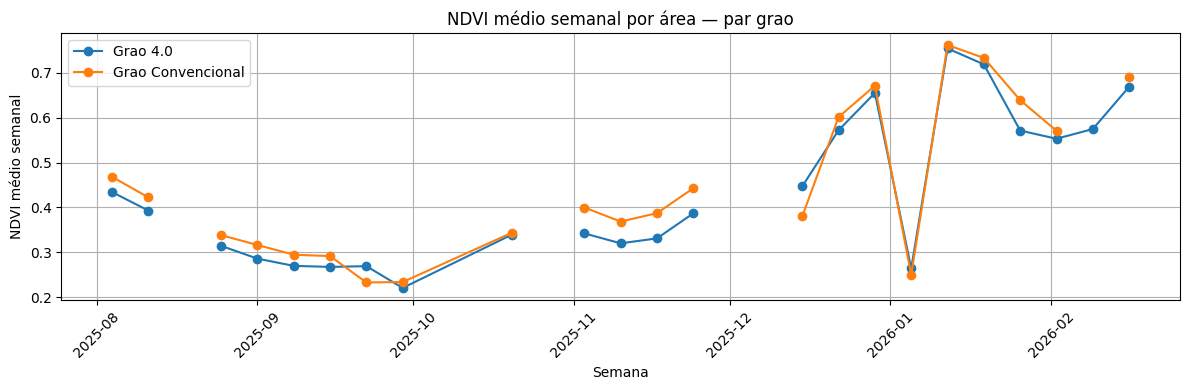

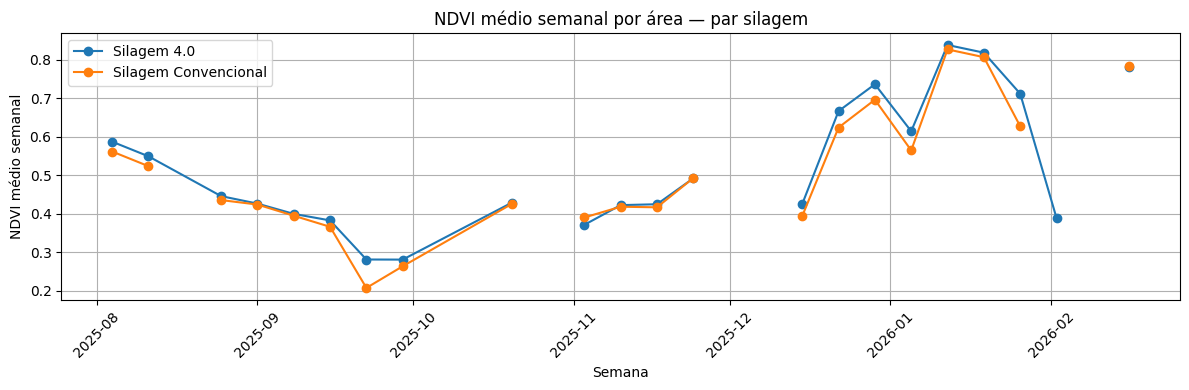

In [31]:

plot_df = ndvi_phase_timeline.copy()
plot_df['week_start'] = pd.to_datetime(plot_df['week_start'])
for pair, sub in plot_df.groupby('comparison_pair'):
    plt.figure(figsize=(12, 4))
    for area, area_df in sub.groupby('area_label'):
        plt.plot(area_df['week_start'], area_df['ndvi_mean_week'], marker='o', label=area)
    plt.title(f'NDVI médio semanal por área — par {pair}')
    plt.xlabel('Semana')
    plt.ylabel('NDVI médio semanal')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



**Leitura:** este gráfico é o coração da hipótese H1. Quando a linha do 4.0 fica acima de forma consistente, isso favorece H1; quando a do convencional fica acima, H1 perde força naquele par.



## 6.2 Gap semanal de NDVI: 4.0 − convencional

- **DataFrame de origem:** `pair_weekly_gaps`
- **Função geradora:** `build_pair_weekly_gaps`
- **Hipótese relacionada:** H1 e H2
- **Pergunta respondida:** em quais semanas o 4.0 ficou acima ou abaixo?


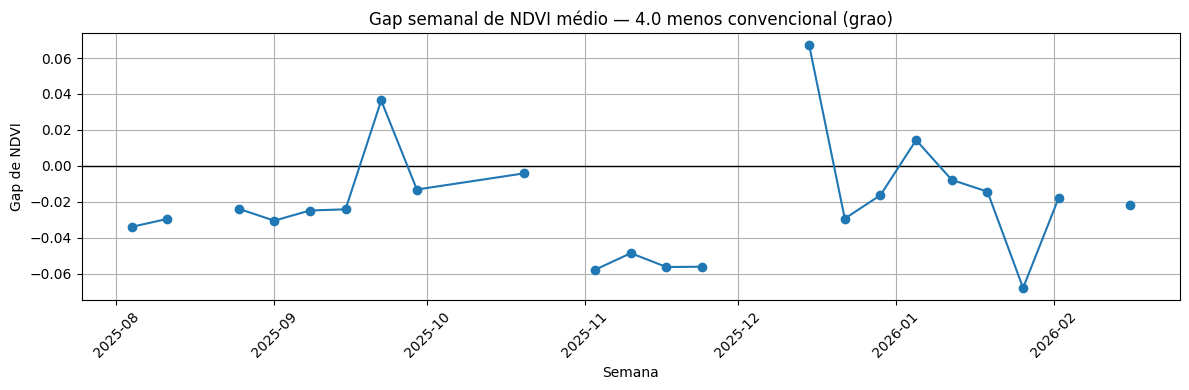

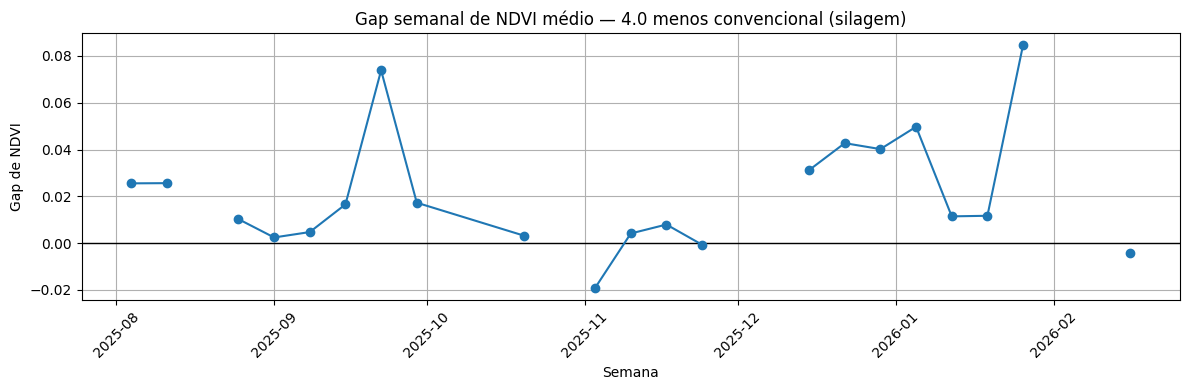

In [32]:

for pair, sub in pair_weekly_gaps.groupby('comparison_pair'):
    x = pd.to_datetime(sub['week_start'])
    y = sub['gap_ndvi_mean_week_4_0_minus_convencional']
    plt.figure(figsize=(12, 4))
    plt.axhline(0, color='black', linewidth=1)
    plt.plot(x, y, marker='o')
    plt.title(f'Gap semanal de NDVI médio — 4.0 menos convencional ({pair})')
    plt.xlabel('Semana')
    plt.ylabel('Gap de NDVI')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



**Leitura:** valores acima de zero favorecem o 4.0; valores abaixo de zero favorecem o convencional. É uma das visualizações mais diretas do efeito temporal.



## 6.3 NDVI médio consolidado por área

- **DataFrame de origem:** `ndvi_stats_by_area`
- **Função geradora:** `build_ndvi_stats_by_area`
- **Hipótese relacionada:** H1


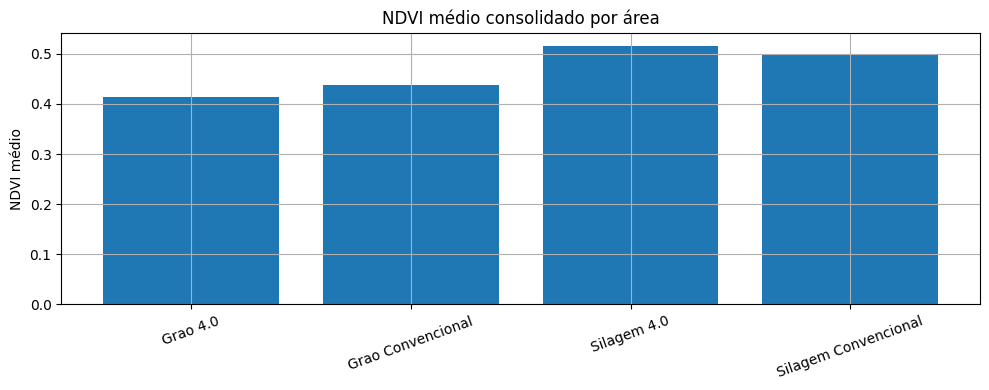

In [33]:

plt.figure(figsize=(10,4))
plt.bar(ndvi_stats_by_area['area_label'], ndvi_stats_by_area['mean'])
plt.title('NDVI médio consolidado por área')
plt.ylabel('NDVI médio')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()



**Leitura:** resume o nível médio global do NDVI por área. Não substitui a leitura temporal, mas ajuda a visualizar o panorama geral.


## 6.4 Outliers de NDVI

- **DataFrame de origem:** `ndvi_outliers`
- **Função geradora:** `build_ndvi_outliers`
- **Pergunta respondida:** quais cenas ficaram muito fora do padrão da própria área?

### Como o gráfico deve ser lido
Cada ponto representa uma cena NDVI. Os pontos maiores são os que receberam `outlier_flag = True`.  
A classificação foi feita comparando cada valor com o comportamento histórico da própria área, e não comparando áreas diferentes entre si.

### Critério usado
Uma cena é marcada como atípica quando:
- `|ndvi_zscore| >= 2.0`, **ou**
- `|ndvi_robust_zscore| >= 3.5`.

Isso significa que o projeto usa duas lentes ao mesmo tempo: uma baseada em média/desvio-padrão e outra baseada em mediana/MAD.


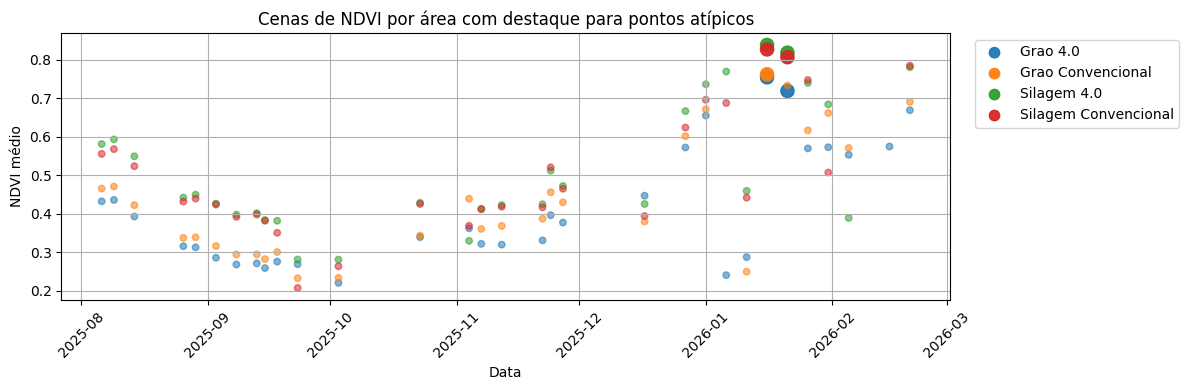

### Resumo dos outliers por área

,area_label,cenas,outliers,por_zscore,por_robust_zscore,menor_zscore,maior_zscore
0,Grao 4.0,31,2,2,0,-1.268447,2.249793
1,Grao Convencional,29,1,1,0,-1.320308,2.079245
2,Silagem 4.0,30,2,0,2,-1.456604,1.998489
3,Silagem Convencional,29,2,1,2,-1.858930,2.087016


shape = (4, 7)


### Exemplos de cenas classificadas como outlier

,area_label,date,ndvi_mean,ndvi_zscore,ndvi_robust_zscore,outlier_direction
0,Grao 4.0,2026-01-16,0.754683,2.249793,3.056586,ndvi_acima_do_padrao
1,Grao 4.0,2026-01-21,0.719268,2.016583,2.780737,ndvi_acima_do_padrao
2,Grao Convencional,2026-01-16,0.762462,2.079245,2.921084,ndvi_acima_do_padrao
3,Silagem 4.0,2026-01-16,0.838768,1.998489,4.068885,ndvi_acima_do_padrao
4,Silagem 4.0,2026-01-21,0.818777,1.874668,3.861819,ndvi_acima_do_padrao
5,Silagem Convencional,2026-01-16,0.827307,2.087016,3.696160,ndvi_acima_do_padrao
6,Silagem Convencional,2026-01-21,0.807069,1.958216,3.503233,ndvi_acima_do_padrao


shape = (7, 6)


In [34]:
out_plot = ndvi_outliers.copy()
out_plot['date'] = pd.to_datetime(out_plot['date'])

plt.figure(figsize=(12,4))
for area, sub in out_plot.groupby('area_label'):
    plt.scatter(
        sub['date'],
        sub['ndvi_mean'],
        s=np.where(sub['outlier_flag'].fillna(False), 90, 22),
        alpha=np.where(sub['outlier_flag'].fillna(False), 0.95, 0.55),
        label=area
    )
plt.title('Cenas de NDVI por área com destaque para pontos atípicos')
plt.xlabel('Data')
plt.ylabel('NDVI médio')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

outlier_summary = (
    ndvi_outliers.assign(
        outlier_flag=ndvi_outliers['outlier_flag'].fillna(False),
        outlier_zscore_flag=ndvi_outliers['outlier_zscore_flag'].fillna(False),
        outlier_robust_flag=ndvi_outliers['outlier_robust_flag'].fillna(False),
    )
    .groupby('area_label', as_index=False)
    .agg(
        cenas=('date', 'count'),
        outliers=('outlier_flag', 'sum'),
        por_zscore=('outlier_zscore_flag', 'sum'),
        por_robust_zscore=('outlier_robust_flag', 'sum'),
        menor_zscore=('ndvi_zscore', 'min'),
        maior_zscore=('ndvi_zscore', 'max'),
    )
)
show_df('Resumo dos outliers por área', outlier_summary, 20)

show_df(
    'Exemplos de cenas classificadas como outlier',
    ndvi_outliers[ndvi_outliers['outlier_flag'].fillna(False)][[
        'area_label','date','ndvi_mean','ndvi_zscore','ndvi_robust_zscore','outlier_direction'
    ]].sort_values(['area_label','date']),
    20,
)



**Leitura:** pontos destacados indicam cenas que ficaram fora do comportamento esperado da série daquela área.


## 6.5 Drivers das semanas-problema

- **DataFrame de origem:** `event_driver_lift`
- **Função geradora:** `build_event_driver_lift`
- **Hipótese relacionada:** H3

### Como o gráfico foi construído
O projeto compara, para cada driver, duas frequências:
- a frequência nas **semanas-problema** (`problem_rate`);
- a frequência nas **semanas normais** (`baseline_rate`).

A barra mostra `delta_pp`, isto é, a diferença entre essas duas taxas em **pontos percentuais**.

### Como interpretar
- barra alta e positiva → o driver apareceu bem mais nas semanas ruins do que nas semanas normais;
- barra perto de zero → o driver não mudou muito de comportamento;
- `lift_ratio` complementa a leitura mostrando a razão entre as duas taxas.

### O que esse gráfico não faz
Ele **não prova causalidade sozinho**. O que ele mostra é sobre-representação: o driver ficou mais presente justamente nas semanas em que o NDVI caiu ou entrou em baixo vigor.


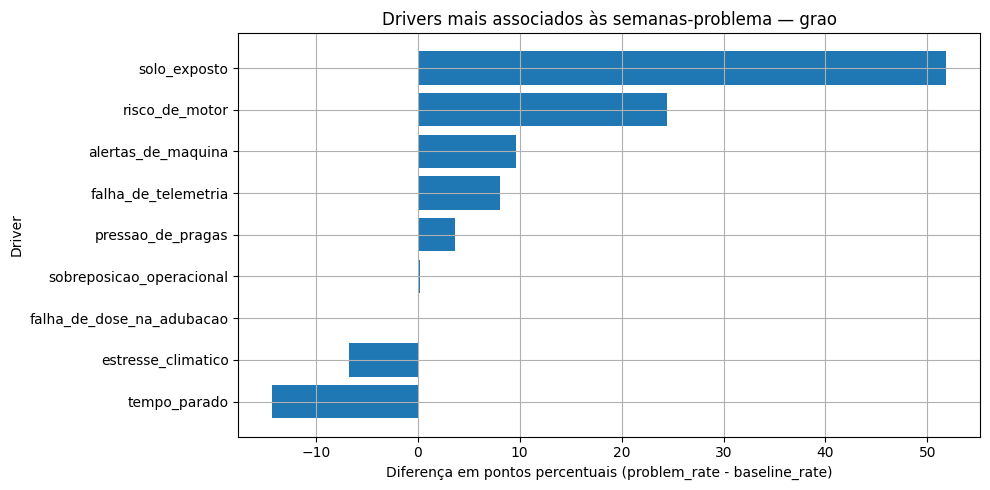

### Tabela de apoio dos drivers — grao

,driver,problem_weeks,problem_rate_%,baseline_rate_%,delta_pp,lift_ratio,evidence_level
0,solo_exposto,27,51.851852,0.000000,51.851852,NaN,alta
1,risco_de_motor,27,85.185185,60.714286,24.470899,1.403050,alta
2,alertas_de_maquina,27,70.370370,60.714286,9.656085,1.159041,baixa
3,falha_de_telemetria,27,25.925926,17.857143,8.068783,1.451852,baixa
4,pressao_de_pragas,27,3.703704,0.000000,3.703704,NaN,baixa
5,sobreposicao_operacional,27,7.407407,7.142857,0.264550,1.037037,baixa
6,falha_de_dose_na_adubacao,27,3.703704,3.571429,0.132275,1.037037,baixa
7,estresse_climatico,27,11.111111,17.857143,-6.746032,0.622222,baixa
8,tempo_parado,27,0.000000,14.285714,-14.285714,0.000000,baixa


shape = (9, 7)


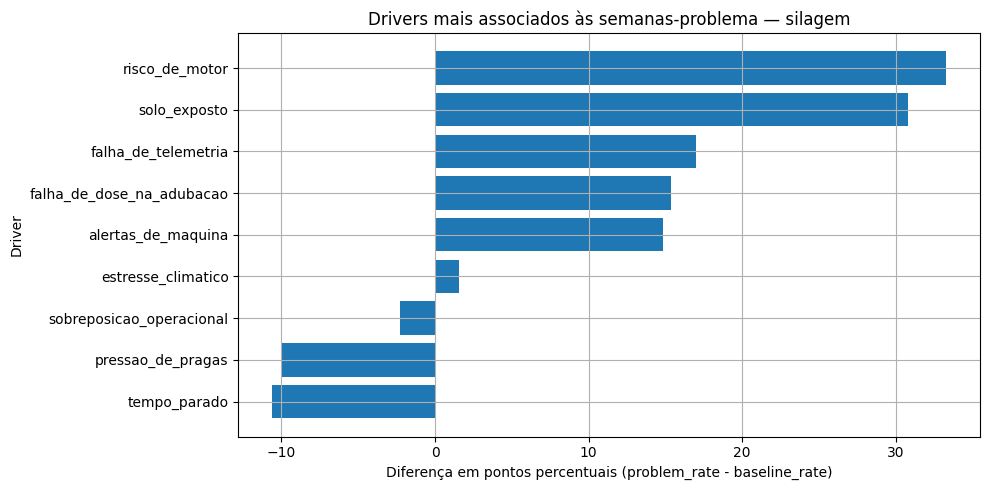

### Tabela de apoio dos drivers — silagem

,driver,problem_weeks,problem_rate_%,baseline_rate_%,delta_pp,lift_ratio,evidence_level
9,risco_de_motor,26,88.461538,55.172414,33.289125,1.603365,alta
10,solo_exposto,26,30.769231,0.000000,30.769231,NaN,alta
11,falha_de_telemetria,26,30.769231,13.793103,16.976127,2.230769,media
12,falha_de_dose_na_adubacao,26,15.384615,0.000000,15.384615,NaN,media
13,alertas_de_maquina,26,76.923077,62.068966,14.854111,1.239316,media
14,estresse_climatico,26,15.384615,13.793103,1.591512,1.115385,baixa
15,sobreposicao_operacional,26,11.538462,13.793103,-2.254642,0.836538,baixa
16,pressao_de_pragas,26,3.846154,13.793103,-9.946950,0.278846,baixa
17,tempo_parado,26,30.769231,41.379310,-10.610080,0.743590,baixa


shape = (9, 7)


In [35]:
driver_plot = event_driver_lift.copy()
driver_plot['problem_rate_pct'] = driver_plot['problem_rate'] * 100
driver_plot['baseline_rate_pct'] = driver_plot['baseline_rate'] * 100

for pair, sub in driver_plot.groupby('comparison_pair'):
    sub = sub.sort_values('delta_pp', ascending=True)
    plt.figure(figsize=(10,5))
    plt.barh(sub['driver'], sub['delta_pp'])
    plt.title(f'Drivers mais associados às semanas-problema — {pair}')
    plt.xlabel('Diferença em pontos percentuais (problem_rate - baseline_rate)')
    plt.ylabel('Driver')
    plt.tight_layout()
    plt.show()

    show_df(
        f'Tabela de apoio dos drivers — {pair}',
        sub[['driver','problem_weeks','problem_rate_pct','baseline_rate_pct','delta_pp','lift_ratio','evidence_level']]
        .rename(columns={
            'problem_rate_pct':'problem_rate_%',
            'baseline_rate_pct':'baseline_rate_%'
        })
        .sort_values('delta_pp', ascending=False),
        20
    )



**Leitura:** esse gráfico mostra o que apareceu mais do que o normal nas semanas em que o NDVI ficou problemático.


## 6.6 Resumo visual das hipóteses H1–H4

- **DataFrame de origem:** `final_hypothesis_register`
- **Função geradora:** `build_final_hypothesis_register`
- **Pergunta respondida:** o que foi suportado, o que não foi suportado e o que ainda ficou inconclusivo?

Em vez de um painel de calor, esta versão usa uma tabela mais legível, porque a leitura textual do status ajuda mais na apresentação.


In [36]:
hyp_table = final_hypothesis_register.copy()
hyp_table['comparison_pair'] = hyp_table['comparison_pair'].str.title()
hyp_table['status'] = hyp_table['status'].str.replace('nao', 'não', regex=False)

pivot_status = hyp_table.pivot(index='comparison_pair', columns='hypothesis_id', values='status')
pivot_basis = hyp_table.pivot(index='comparison_pair', columns='hypothesis_id', values='proof_basis')

def color_status(val):
    val = str(val).lower()
    if 'suportad' in val and 'não' not in val and 'nao' not in val:
        return 'background-color: #d9f2d9'
    if 'inconclus' in val:
        return 'background-color: #fff4cc'
    if 'não suportad' in val or 'nao suportad' in val:
        return 'background-color: #f8d7da'
    return ''

display(
    pivot_status.style
    .applymap(color_status)
    .set_caption('Status das hipóteses por par')
)

for pair in pivot_basis.index:
    md(f"### Base resumida das hipóteses — {pair}")
    display(pivot_basis.loc[[pair]].T.rename(columns={pair: 'base_da_decisao'}))


/tmp/ipykernel_23852/456685975.py:20: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_status)


hypothesis_id,H1,H2,H3,H4
comparison_pair,,,,
Grao,não_suportada,inconclusiva,suportada,inconclusiva
Silagem,suportada,inconclusiva,suportada,não_suportada


### Base resumida das hipóteses — Grao

comparison_pair,base_da_decisao
hypothesis_id,
H1,"NDVI medio semanal: vantagem_4_0=-0.021, IC95% [-0.032, -0.008], p=0.007, evidencia=alta."
H2,"Semanas de baixo vigor: vantagem_4_0=-0.037, IC95% [-0.148, 0.074], p=1.000, evidencia=baixa. | Semanas de queda relevante: vantagem_4_0=0.037, IC95% [0.000, 0.111], p=1.000, evidencia=baixa."
H3,"Driver dominante: solo_exposto com delta=51.852 pp, lift=NA, evidencia=alta."
H4,"Outlook 4.0: score=71.300, faixa=positivo_com_ressalvas, esperado=sem_vantagem_clara_no_par, riscos=risco_operacional | baixo_vigor_recorrente | telemetria_instavel."


### Base resumida das hipóteses — Silagem

comparison_pair,base_da_decisao
hypothesis_id,
H1,"NDVI medio semanal: vantagem_4_0=0.021, IC95% [0.011, 0.032], p=0.000, evidencia=alta."
H2,"Semanas de baixo vigor: vantagem_4_0=-0.111, IC95% [-0.259, 0.000], p=0.253, evidencia=baixa. | Semanas de queda relevante: vantagem_4_0=0.000, IC95% [-0.111, 0.111], p=1.000, evidencia=baixa."
H3,"Driver dominante: risco_de_motor com delta=33.289 pp, lift=1.603, evidencia=alta."
H4,"Outlook 4.0: score=70.400, faixa=positivo_com_ressalvas, esperado=tende_a_chegar_abaixo_do_par, riscos=risco_operacional | baixo_vigor_recorrente."



**Leitura:** aqui você enxerga rapidamente o fechamento formal das hipóteses por par.


# 7. Leitura integrada dos resultados

Nesta etapa, os resultados são reunidos em uma explicação única, conectando os gráficos, os testes e os limites do pacote de dados.


In [37]:

show_df('Resumo decisório final por par', decision_summary, 10)


### Resumo decisório final por par

,comparison_pair,temporal_winner,ndvi_effect_direction,ndvi_effect_value,top_problem_driver,supported_hypotheses,not_supported_hypotheses,expected_vs_pair_4_0,decision_message,next_step
0,grao,convencional,favorece_convencional,-0.020888,solo_exposto,1,1,sem_vantagem_clara_no_par,"No par grao, o convencional segue a referencia temporal de NDVI; o principal bloco de risco associado e solo_exposto; o outlook 4.0 atual e sem_vantagem_clara_no_par.",Coletar mais cobertura e revisar solo_exposto antes de fechar conclusao executiva no par grao.
1,silagem,convencional,favorece_4_0,0.020939,risco_de_motor,2,1,tende_a_chegar_abaixo_do_par,"No par silagem, o 4.0 sustenta vantagem temporal de NDVI; o principal bloco de risco associado e risco_de_motor; o outlook 4.0 atual e tende_a_chegar_abaixo_do_par.",Priorizar plano corretivo em risco_de_motor e reavaliar a aderencia operacional do 4.0 no par silagem.


shape = (2, 10)


## O que aconteceu no par grão

No par **grão**, o projeto encontrou um cenário em que o **convencional** ficou acima do 4.0 no comportamento temporal do NDVI. Isso aparece nos testes principais e nos gaps semanais. O driver mais associado às semanas-problema foi **solo exposto**, o que sugere que parte da perda de desempenho vegetativo está associada à condição de cobertura da área e não apenas à presença ou ausência de tecnologia.

## O que aconteceu no par silagem

No par **silagem**, o **4.0** apareceu acima do convencional no NDVI médio semanal e também na área sob a curva. Ao mesmo tempo, as semanas-problema desse par apontaram mais fortemente para **risco de motor**, mostrando que, mesmo onde o 4.0 foi melhor no vigor vegetativo, ainda existiam sinais operacionais relevantes.

## Por que o 4.0 não foi melhor no geral

Porque o projeto não mede “tecnologia” como um selo automático de melhor resultado. O que ele mede é o **resultado observado no campo**, e esse resultado depende da combinação entre:
- fase do ciclo;
- condição da cobertura do solo;
- clima;
- pressão de pragas;
- consistência operacional;
- telemetria e eventos de máquina.

Por isso, o 4.0 pode aparecer melhor em um par e não em outro.

## Por que houve queda e depois recuperação

Porque o projeto trabalha com uma timeline semanal e classifica eventos. Nem toda queda significa colapso da lavoura. Algumas quedas fazem parte da transição de fase; outras sinalizam baixo vigor, estresse ou desvio operacional. A recuperação aparece quando a série volta a subir depois dessas semanas mais fracas.

## O que já está sustentado pelos dados

- existe diferença temporal de NDVI entre os pares;
- essa diferença não foi uniforme entre grão e silagem;
- há drivers sobre-representados nas semanas-problema;
- a camada econômica ainda não está fechada com o mesmo nível de robustez.


# 8. Fechamento

A forma mais clara de entender o projeto é seguir esta ordem:

1. bruto (`ndvi_metadata.csv`, Metos, EKOS, MIIP, solo);
2. `ndvi_clean.csv`;
3. `ndvi_phase_timeline.csv`;
4. `pair_weekly_gaps.csv`, `ndvi_stats_by_area.csv`, `ndvi_outliers.csv`;
5. `pair_effect_tests.csv`, `pair_classic_tests.csv`, `weekly_correlations.csv`, `event_driver_lift.csv`;
6. `final_hypothesis_register.csv` e `decision_summary.csv`.

Seguindo essa ordem, fica mais fácil enxergar como o dado bruto vira evidência estatística e, por fim, narrativa analítica.
